In [3]:
import polars as pl
from rich import print

In [4]:
# Configure Polars to show everything
pl.Config.set_tbl_cols(-1)  # Show all columns
pl.Config.set_tbl_rows(10)  # Show up to 10 rows
pl.Config.set_fmt_str_lengths(100)  # Don't truncate long strings/lists
pl.Config.set_tbl_width_chars(1000)  # Allow a wide display

polars.config.Config

In [124]:
df = pl.read_parquet("merged.parquet")
# Filter to ground truth: Only NC Vascular Plants
df_nc_native = df.filter(pl.col("vasc_id").is_not_null())

print(f"Total records anchored to VASC ground truth: {df_nc_native.height}")

# Fill Nulls based on data type for the whole DataFrame
df = df.with_columns(
    [
        pl.col(pl.Utf8).fill_null(""),  # All strings become ""
        pl.col(pl.List(pl.Utf8)).fill_null([]),  # All lists of strings become []
        pl.col(pl.Boolean).fill_null(False),  # All null booleans become False
    ]
)

Total records anchored to VASC ground truth: 3351

In [125]:
import polars as pl

# Patterns
quoted_pattern = r'"([^"]+)"'

# Refined name_pattern (Hyphen-Safe):
# [A-Z][a-z\-]+ -> Match a Capital letter followed by lowercase letters OR hyphens
# (?:[ -][A-Z][a-z\-]+){1,4} -> Match 1 to 4 subsequent words starting with Caps
name_pattern = r"\b[A-Z][a-z\-]+(?:[ -][A-Z][a-z\-]+){1,4}\b"

junk_words = ["Most", "With", "Reference", "Some", "From", "This", "When", "There"]

df = df.with_columns(
    vasc_other_common_names_clean=(
        pl.col("vasc_other_common_names")
        .str.extract_all(quoted_pattern)
        .fill_null([])
        .list.concat(
            # Replace periods with pipes to create a hard stop
            pl.col("vasc_other_common_names").str.replace_all(r"\.", "|").str.extract_all(name_pattern).fill_null([])
        )
        .list.eval(
            pl.element()
            .str.strip_chars(' "|.')
            .str.replace_all(r"x+", "")
            .str.strip_chars("- ")  # Clean up trailing hyphens if any
            .filter(
                (~pl.element().is_in(junk_words))
                & (pl.element().str.len_chars() > 3)
                & (pl.element().str.contains(r"[ -]"))
            )
        )
        .list.unique()
    )
)

In [126]:
# 1. Define the specific columns for this merge
# We use the 'clean' version for the messy VASC column
cols_to_merge = [
    "vasc_common_name_primary",
    "pm_Common Name",
    "ncsu_other_common_names",
    "vasc_other_common_names_clean",
]

# 2. Get the schema to handle List vs String types automatically
schema = df.schema

processing_exprs = []
for col_name in cols_to_merge:
    dtype = schema.get(col_name)

    if isinstance(dtype, pl.List):
        # If it's our cleaned list, join it into a string temporarily
        expr = pl.col(col_name).list.join(", ")
    else:
        # If it's a string, cast to Utf8 and handle nulls
        expr = pl.col(col_name).cast(pl.Utf8)

    processing_exprs.append(expr.fill_null(""))

# 3. Create the final 'all_common_names' Master Column
df_final = df.with_columns(
    all_common_names=(
        pl.concat_str(processing_exprs, separator=", ")
        .str.split(", ")
        .list.eval(
            pl.element()
            .str.strip_chars(" .")  # Final polish for trailing dots or spaces
            .filter((pl.element() != "") & (pl.element().is_not_null()))
        )
        .list.unique()
    )
)

# 4. Final Verification: Check the merge results
# We include 'scientific_name' to provide context for the names
verification_cols = ["scientific_name"] + cols_to_merge + ["all_common_names"]

pl.Config.set_fmt_str_lengths(100)
print(df_final.select(verification_cols).head(10))

shape: (10, 6)
┌────────────────────────────────────────┬──────────────────────────┬────────────────┬─────────────────────────────
───────────────────────────────────────────┬──────────────────────────────────────────────────────┬────────────────
─────────────────────────────────────────────────────────┐
│ scientific_name                        ┆ vasc_common_name_primary ┆ pm_Common Name ┆ ncsu_other_common_names     
┆ vasc_other_common_names_clean                        ┆ all_common_names                                          
│
│ ---                                    ┆ ---                      ┆ ---            ┆ ---                         
┆ ---                                                  ┆ ---                                                       
│
│ str                                    ┆ str                      ┆ str            ┆ list[str]                   
┆ list[str]                                            ┆ list[str]                                                 
│
╞════════════════════════════════════════╪══════════════════════════╪════════════════╪═════════════════════════════
═══════════════════════════════════════════╪══════════════════════════════════════════════════════╪════════════════
═════════════════════════════════════════════════════════╡
│ huperzia appressa                      ┆ Appalachian Firmoss      ┆                ┆ []                          
┆ ["Mountain Firmoss", "Appalachian Fir-clubmoss"]     ┆ ["Appalachian Firmoss", "Appalachian Fir-clubmoss", 
"Mountain Firmoss"] │
│ huperzia lucidula                      ┆ Shining Clubmoss         ┆                ┆ ["Shining Clubmoss", 
"Shining Firmoss"]                                ┆ ["Shining Clubmoss", "Shining Firmoss", … "Firmoss"] ┆ 
["Shining Clubmoss", "Firmoss", … "Shining Firmoss"]                    │
│ huperzia porophila                     ┆ Rock Firmoss             ┆                ┆ []                          
┆ ["Firmoss", "Clubmoss", … "Rock Firmoss"]            ┆ ["Rock Firmoss", "Firmoss", … "Rock Clubmoss"]            
│
│ dendrolycopodium dendroideum           ┆ Tree Ground              ┆                ┆ []                          
┆ []                                                   ┆ ["Tree Ground"]                                           
│
│ dendrolycopodium hickeyi               ┆ Pennsylvania Ground      ┆                ┆ []                          
┆ []                                                   ┆ ["Pennsylvania Ground"]                                   
│
│ dendrolycopodium obscurum              ┆ Common Ground            ┆                ┆ ["Common Ground Pine", 
"Flat-branched Ground-pine", … "Tree Clubmoss"] ┆ []                                                   ┆ ["Princess
Pine", "Rare Clubmoss", … "Common Ground"]                   │
│ diphasiastrum digitatum                ┆ Southern Ground          ┆                ┆ ["Clubmoss", "Common 
Running-cedar", … "Running Cedar"]                ┆ []                                                   ┆ ["Fan 
Ground-pine", "Clubmoss", … "Common Running-cedar"]               │
│ diphasiastrum tristachyum              ┆ Blue Ground              ┆                ┆ []                          
┆ []                                                   ┆ ["Blue Ground"]                                           
│
│ lycopodiella alopecuroides             ┆ Foxtail Clubmoss +       ┆                ┆ []                          
┆ []                                                   ┆ ["Foxtail Clubmoss +"]                                    
│
│ lycopodiella alopecuroides x prostrata ┆ a hybrid clubmoss        ┆                ┆ []                          
┆ []                                                   ┆ ["a hybrid clubmoss"]                                     
│
└────────────────────────────────────────┴──────────────────────────┴────────────────┴─────────────────────────────
───────────────────────────────────────────┴─────────────────

shape: (5, 1)
┌─────────────────────────────────────────────────────────────────────────┐
│ all_common_names                                                        │
│ ---                                                                     │
│ list[str]                                                               │
╞═════════════════════════════════════════════════════════════════════════╡
│ ["Appalachian Fir-clubmoss", "Appalachian Firmoss", "Mountain Firmoss"] │
│ ["Clubmoss", "Shining Clubmoss", … "Firmoss"]                           │
│ ["Rock Clubmoss", "Clubmoss", … "Firmoss"]                              │
│ ["Tree Ground"]                                                         │
│ ["Pennsylvania Ground"]                                                 │
└─────────────────────────────────────────────────────────────────────────┘

In [127]:
# 1. Standardize and Merge Strings
df_final = df_nc_native.with_columns(
    [
        # WILDLIFE: Combine PM + NCSU Attracts + NCSU Wildlife Value
        pl.concat_str(
            [
                pl.when(pl.col("pm_adv_bee") == True).then(pl.lit("Bees")).otherwise(pl.lit("")),
                pl.when(pl.col("pm_adv_bird") == True).then(pl.lit("Birds")).otherwise(pl.lit("")),
                pl.col("ncsu_Attracts").cast(pl.Utf8).fill_null(""),
            ],
            separator=",",
        ).alias("_wildlife_raw"),
        # RESISTANCE: Combine PM Deer + NCSU Resistance + NCSU Problems (Resistant To)
        pl.concat_str(
            [
                pl.when(pl.col("pm_adv_deer") == True).then(pl.lit("Deer")).otherwise(pl.lit("")),
                pl.col("ncsu_Resistance To Challenges").cast(pl.Utf8).fill_null(""),
            ],
            separator=",",
        ).alias("_res_raw"),
    ]
)


# 2. Convert to Clean Lists
def final_tag_cleanup(col):
    return (
        pl.col(col)
        .str.replace_all(r'[\[\]"\' ]', " ")
        .str.split(",")
        .list.eval(pl.element().str.strip_chars(" .").str.to_titlecase().filter(pl.element().str.len_chars() > 2))
        .list.unique()
    )


df_final = df_final.with_columns(
    [
        final_tag_cleanup("_wildlife_raw").alias("wildlife_attracts"),
        final_tag_cleanup("_res_raw").alias("plant_resistances"),
    ]
).drop(["_wildlife_raw", "_res_raw"])

# 4. Verify with an NC staple: Asclepias tuberosa (Butterfly Weed)
print(
    df_final.filter(pl.col("scientific_name").str.contains("asclepias tuberosa")).select(
        [
            "scientific_name",
            pl.col("wildlife_attracts").list.join(", ").alias("Attracts"),
            pl.col("plant_resistances").list.join(", ").alias("Resists"),
        ]
    )
)

shape: (2, 3)
┌─────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────┬─
──────────────────────────────────────┐
│ scientific_name                 ┆ Attracts                                                                     ┆ 
Resists                               │
│ ---                             ┆ ---                                                                          ┆ 
---                                   │
│ str                             ┆ str                                                                          ┆ 
str                                   │
╞═════════════════════════════════╪══════════════════════════════════════════════════════════════════════════════╪═
══════════════════════════════════════╡
│ asclepias tuberosa              ┆ Birds, Moths, Specialized Bees, Butterflies, Bees, Hummingbirds, Pollinators ┆ 
Salt, Erosion, Drought, Rabbits, Deer │
│ asclepias tuberosa var. rolfsii ┆                                                                              ┆ 
│
└─────────────────────────────────┴──────────────────────────────────────────────────────────────────────────────┴─
──────────────────────────────────────┘

In [78]:
# 1. Filter specifically for rows that HAVE height data in either column
# We explode the lists so we can see the actual string contents
height_samples = (
    df.filter(pl.col("pm_Height").is_not_null() | pl.col("ncsu_Dimensions").is_not_null())
    .select(
        [
            "scientific_name",
            # Convert list to string or take the first element to see the format
            pl.col("pm_Height").list.join(" / ").alias("pm_raw"),
            pl.col("ncsu_Dimensions").list.join(" / ").alias("ncsu_raw"),
        ]
    )
    .head(20)
)

print(height_samples)

# 2. Check the most common unique formats to identify units/delimiters
print("\nUnique PM Height Examples:")
print(df.select("pm_Height").explode("pm_Height").unique().head(10))

print("\nUnique NCSU Dimension Examples:")
print(df.select("ncsu_Dimensions").explode("ncsu_Dimensions").unique().head(10))

shape: (20, 3)
┌─────────────────────────┬────────┬───────────────────────────────────────────────────────────────────────┐
│ scientific_name         ┆ pm_raw ┆ ncsu_raw                                                              │
│ ---                     ┆ ---    ┆ ---                                                                   │
│ str                     ┆ str    ┆ str                                                                   │
╞═════════════════════════╪════════╪═══════════════════════════════════════════════════════════════════════╡
│ diphasiastrum digitatum ┆ null   ┆ Height: 0 ft. 3 in. - 0 ft. 8 in. / Width: 0 ft. 6 in. - 1 ft. 0 in.  │
│ lycopodiella appressa   ┆ null   ┆ Height: 0 ft. 5 in. - 1 ft. 0 in. / Width: 1 ft. 0 in. - 1 ft. 6 in.  │
│ equisetum praealtum     ┆ null   ┆ Height: 1 ft. 0 in. - 11 ft. 0 in. / Width: 1 ft. 0 in. - 6 ft. 0 in. │
│ botrypus virginianus    ┆ null   ┆ Height: 0 ft. 6 in. - 4 ft. 0 in. / Width: 0 ft. 8 in. - 1 ft. 0 in.  │
│ sceptridium dissectum   ┆ null   ┆ Height: 0 ft. 6 in. - 1 ft. 6 in. / Width: 0 ft. 4 in. - 0 ft. 6 in.  │
│ …                       ┆ …      ┆ …                                                                     │
│ cystopteris protrusa    ┆ null   ┆ Height: 0 ft. 6 in. - 1 ft. 6 in. / Width: 0 ft. 6 in. - 1 ft. 6 in.  │
│ diplaziopsis pycnocarpa ┆ null   ┆ Height: 2 ft. 0 in. - 3 ft. 0 in. / Width: 2 ft. 0 in. - 3 ft. 0 in.  │
│ asplenium platyneuron   ┆ null   ┆ Height: 0 ft. 8 in. - 1 ft. 8 in. / Width: 0 ft. 8 in. - 1 ft. 8 in.  │
│ asplenium rhizophyllum  ┆ null   ┆ Height: 0 ft. 2 in. - 1 ft. 0 in. / Width: 0 ft. 2 in. - 1 ft. 0 in.  │
│ asplenium trichomanes   ┆ null   ┆ Height: 0 ft. 4 in. - 0 ft. 7 in. / Width: 0 ft. 4 in. - 0 ft. 7 in.  │
└─────────────────────────┴────────┴───────────────────────────────────────────────────────────────────────┘

Unique PM Height Examples:

shape: (9, 1)
┌───────────────────┐
│ pm_Height         │
│ ---               │
│ str               │
╞═══════════════════╡
│ 2' to 3'          │
│ null              │
│ 6' to 10'         │
│ 4' to 6'          │
│ 6&quot; and under │
│ 10' and over      │
│ 1' to 2'          │
│ 3' to 4'          │
│ 6&quot; to 1'     │
└───────────────────┘

Unique NCSU Dimension Examples:

shape: (10, 1)
┌─────────────────────────────────────┐
│ ncsu_Dimensions                     │
│ ---                                 │
│ str                                 │
╞═════════════════════════════════════╡
│ Height: 0 ft. 3 in. - 0 ft. 8 in.   │
│ Height: 5 ft. 0 in. - 7 ft. 0 in.   │
│ Height: 20 ft. 0 in. - 30 ft. 0 in. │
│ Height: 1 ft. 0 in. - 2 ft. 0 in.   │
│ Height: 60 ft. 0 in. - 70 ft. 0 in. │
│ Width: 0 ft. 6 in. - 6 ft. 0 in.    │
│ Width: 5 ft. 0 in. - 10 ft. 0 in.   │
│ Height: 0 ft. 8 in. - 2 ft. 0 in.   │
│ Height: 6 ft. 0 in. - 10 ft. 0 in.  │
│ Height: 3 ft. 0 in. - 6 ft. 0 in.   │
└─────────────────────────────────────┘

In [85]:
import polars as pl


def parse_dimensions(df):
    # 1. Flatten list columns into strings
    df_working = df.with_columns(
        [
            pl.col("pm_Height").list.join(" ").fill_null("").alias("_pm_raw"),
            pl.col("ncsu_Dimensions").list.join(" ").fill_null("").alias("_ncsu_raw"),
        ]
    )

    # 2. Isolate NCSU segments
    df_working = df_working.with_columns(
        [
            pl.col("_ncsu_raw").str.extract(r"(?i)height:\s*(.*?)(?:width:|$)").alias("_ncsu_h_seg"),
            pl.col("_ncsu_raw").str.extract(r"(?i)width:\s*(.*)").alias("_ncsu_w_seg"),
        ]
    )

    def extract_stats(col_expr):
        # Normalize and clean markers
        clean = (
            col_expr.str.to_lowercase()
            .str.replace_all(r"&quot;", '"')
            .str.replace_all(r"ft\.|feet|'", "ft")
            .str.replace_all(r"in\.|inches|\"", "in")
        )

        # 3. Extract feet and inches safely using list methods that handle empty lists
        ft_list = clean.str.extract_all(r"\d+(?:\.\d+)?\s*ft").list.eval(
            pl.element().str.replace("ft", "").str.strip_chars().cast(pl.Float64)
        )
        in_list = clean.str.extract_all(r"\d+(?:\.\d+)?\s*in").list.eval(
            pl.element().str.replace("in", "").str.strip_chars().cast(pl.Float64)
        )

        # General fallback for raw numbers
        num_list = clean.str.extract_all(r"\d+(?:\.\d+)?").list.eval(pl.element().cast(pl.Float64))

        # Safe extraction: .list.get(0, null_on_oob=True) prevents the Out of Bounds error
        f1 = ft_list.list.get(0, null_on_oob=True).fill_null(0.0)
        f2 = ft_list.list.get(1, null_on_oob=True).fill_null(0.0)
        i1 = in_list.list.get(0, null_on_oob=True).fill_null(0.0)
        i2 = in_list.list.get(1, null_on_oob=True).fill_null(0.0)

        # Calculate decimal feet
        v1_ft = f1 + (i1 / 12.0)
        v2_ft = f2 + (i2 / 12.0)

        fallback_v1 = num_list.list.get(0, null_on_oob=True)
        fallback_v2 = num_list.list.get(1, null_on_oob=True).fill_null(fallback_v1)

        # Final Min/Max Logic: prioritize the ft/in calculated value if it's > 0
        final_min = pl.when(v1_ft > 0).then(v1_ft).otherwise(fallback_v1)

        # If v2_ft exists and is > 0, use it. Otherwise use fallback_v2.
        # If those are null, fallback to final_min.
        final_max = pl.when(v2_ft > 0).then(v2_ft).otherwise(fallback_v2).fill_null(final_min)

        return final_min, final_max

    # 4. Apply
    pm_h_min, pm_h_max = extract_stats(pl.col("_pm_raw"))
    ncsu_h_min, ncsu_h_max = extract_stats(pl.col("_ncsu_h_seg"))
    ncsu_w_min, ncsu_w_max = extract_stats(pl.col("_ncsu_w_seg"))

    # 5. Combine (PM Priority for height)
    df_final = df_working.with_columns(
        [
            pl.coalesce([pm_h_min, ncsu_h_min]).alias("height_min_ft"),
            pl.coalesce([pm_h_max, ncsu_h_max]).alias("height_max_ft"),
            ncsu_w_min.alias("width_min_ft"),
            ncsu_w_max.alias("width_max_ft"),
        ]
    )

    # 6. Display formatting
    return df_final.with_columns(
        [
            pl.when(pl.col("height_min_ft").is_not_null())
            .then(pl.format("{}–{} ft", pl.col("height_min_ft").round(1), pl.col("height_max_ft").round(1)))
            .otherwise(pl.lit("Unknown"))
            .alias("height_str"),
            pl.when(pl.col("width_min_ft").is_not_null())
            .then(pl.format("{}–{} ft", pl.col("width_min_ft").round(1), pl.col("width_max_ft").round(1)))
            .otherwise(pl.lit("Unknown"))
            .alias("width_str"),
        ]
    ).drop(["_pm_raw", "_ncsu_raw", "_ncsu_h_seg", "_ncsu_w_seg"])


# Run the parser on your NC Native dataframe
df_final = parse_dimensions(df_nc_native)

print(df_final.select(["scientific_name", "height_str", "width_str"]).head())

shape: (5, 3)
┌──────────────────────────────┬────────────┬───────────┐
│ scientific_name              ┆ height_str ┆ width_str │
│ ---                          ┆ ---        ┆ ---       │
│ str                          ┆ str        ┆ str       │
╞══════════════════════════════╪════════════╪═══════════╡
│ huperzia appressa            ┆ Unknown    ┆ Unknown   │
│ huperzia lucidula            ┆ Unknown    ┆ Unknown   │
│ huperzia porophila           ┆ Unknown    ┆ Unknown   │
│ dendrolycopodium dendroideum ┆ Unknown    ┆ Unknown   │
│ dendrolycopodium hickeyi     ┆ Unknown    ┆ Unknown   │
└──────────────────────────────┴────────────┴───────────┘

In [87]:
# Check rows where we actually found data
print(
    df_final.filter(pl.col("height_str") != "Unknown").select(["scientific_name", "height_str", "width_str"]).head(20)
)

shape: (20, 3)
┌─────────────────────────┬─────────────┬────────────┐
│ scientific_name         ┆ height_str  ┆ width_str  │
│ ---                     ┆ ---         ┆ ---        │
│ str                     ┆ str         ┆ str        │
╞═════════════════════════╪═════════════╪════════════╡
│ diphasiastrum digitatum ┆ 0.2–0.7 ft  ┆ 0.5–1.0 ft │
│ lycopodiella appressa   ┆ 0.4–1.0 ft  ┆ 1.0–1.5 ft │
│ equisetum praealtum     ┆ 1.0–11.0 ft ┆ 1.0–6.0 ft │
│ botrypus virginianus    ┆ 0.5–4.0 ft  ┆ 0.7–1.0 ft │
│ sceptridium dissectum   ┆ 0.5–1.5 ft  ┆ 0.3–0.5 ft │
│ …                       ┆ …           ┆ …          │
│ cystopteris protrusa    ┆ 0.5–1.5 ft  ┆ 0.5–1.5 ft │
│ diplaziopsis pycnocarpa ┆ 2.0–3.0 ft  ┆ 2.0–3.0 ft │
│ asplenium platyneuron   ┆ 0.7–1.7 ft  ┆ 0.7–1.7 ft │
│ asplenium rhizophyllum  ┆ 0.2–1.0 ft  ┆ 0.2–1.0 ft │
│ asplenium trichomanes   ┆ 0.3–0.6 ft  ┆ 0.3–0.6 ft │
└─────────────────────────┴─────────────┴────────────┘

In [90]:
# Filter for a plant known to exist in both datasets with full data
verification_df = df_final.filter(pl.col("scientific_name").str.contains("asclepias tuberosa"))

# Display the raw inputs alongside our parsed results
print(
    verification_df.select(
        [
            "scientific_name",
            pl.col("pm_Height").list.join(", ").alias("PM Raw"),
            pl.col("ncsu_Dimensions").list.join(", ").alias("NCSU Raw"),
            "height_str",
            "width_str",
        ]
    )
)

shape: (2, 2)
┌─────────────────────────────────┬─────────────────────────────────────────────────────────────────────┐
│ scientific_name                 ┆ NCSU Raw                                                            │
│ ---                             ┆ ---                                                                 │
│ str                             ┆ str                                                                 │
╞═════════════════════════════════╪═════════════════════════════════════════════════════════════════════╡
│ asclepias tuberosa              ┆ Height: 1 ft. 0 in. - 2 ft. 0 in., Width: 1 ft. 0 in. - 1 ft. 6 in. │
│ asclepias tuberosa var. rolfsii ┆ null                                                                │
└─────────────────────────────────┴─────────────────────────────────────────────────────────────────────┘

In [92]:
stats = df_final.select(
    [
        pl.col("pm_Height").is_not_null().sum().alias("has_pm_data"),
        pl.col("ncsu_Dimensions").is_not_null().sum().alias("has_ncsu_data"),
        (pl.col("pm_Height").is_not_null() & pl.col("ncsu_Dimensions").is_not_null()).sum().alias("has_both"),
        pl.len().alias("total_nc_natives"),
    ]
)

print(stats)

shape: (1, 4)
┌─────────────┬───────────────┬──────────┬──────────────────┐
│ has_pm_data ┆ has_ncsu_data ┆ has_both ┆ total_nc_natives │
│ ---         ┆ ---           ┆ ---      ┆ ---              │
│ u32         ┆ u32           ┆ u32      ┆ u32              │
╞═════════════╪═══════════════╪══════════╪══════════════════╡
│ 392         ┆ 751           ┆ 195      ┆ 3351             │
└─────────────┴───────────────┴──────────┴──────────────────┘

In [93]:
# Look for the first 10 plants that actually have a height value
success_check = (
    df_final.filter(pl.col("height_str") != "Unknown").select(["scientific_name", "height_str", "width_str"]).head(10)
)

if success_check.height > 0:
    print("Successfully parsed dimensions for these plants:")
    print(success_check)
else:
    print("Warning: No heights were parsed. We may need to check the column types.")

Successfully parsed dimensions for these plants:

shape: (10, 3)
┌───────────────────────────┬─────────────┬────────────┐
│ scientific_name           ┆ height_str  ┆ width_str  │
│ ---                       ┆ ---         ┆ ---        │
│ str                       ┆ str         ┆ str        │
╞═══════════════════════════╪═════════════╪════════════╡
│ diphasiastrum digitatum   ┆ 0.2–0.7 ft  ┆ 0.5–1.0 ft │
│ lycopodiella appressa     ┆ 0.4–1.0 ft  ┆ 1.0–1.5 ft │
│ equisetum praealtum       ┆ 1.0–11.0 ft ┆ 1.0–6.0 ft │
│ botrypus virginianus      ┆ 0.5–4.0 ft  ┆ 0.7–1.0 ft │
│ sceptridium dissectum     ┆ 0.5–1.5 ft  ┆ 0.3–0.5 ft │
│ claytosmunda claytoniana  ┆ 2.0–4.0 ft  ┆ 2.0–4.0 ft │
│ osmunda spectabilis       ┆ 2.0–5.0 ft  ┆ 2.0–3.0 ft │
│ osmundastrum cinnamomeum  ┆ 2.0–6.0 ft  ┆ 2.0–4.0 ft │
│ lygodium palmatum         ┆ 6.0–9.0 ft  ┆ 6.0–8.0 ft │
│ adiantum capillus-veneris ┆ 0.8–2.0 ft  ┆ 0.8–2.0 ft │
└───────────────────────────┴─────────────┴────────────┘

In [105]:
import polars as pl


# A small helper to join lists but leave strings alone
def safe_join(col_name):
    # We check the schema of df_final to see if it's a list type
    dtype = df_final.schema.get(col_name)
    if isinstance(dtype, pl.List):
        return pl.col(col_name).list.join(", ")
    else:
        return pl.col(col_name).cast(pl.Utf8)


bloom_samples = (
    df_final.filter(
        pl.col("pm_Bloom Time").is_not_null()
        | pl.col("ncsu_Flower Bloom Time").is_not_null()
        | pl.col("vasc_phenology").is_not_null()
    )
    .select(
        [
            "scientific_name",
            safe_join("pm_Bloom Time").alias("pm_bloom_raw"),
            safe_join("ncsu_Flower Bloom Time").alias("ncsu_bloom_raw"),
            safe_join("vasc_phenology").alias("vasc_phenology_raw"),
            safe_join("ncsu_Flower Color").alias("flower_color_raw"),
        ]
    )
    .head(20)
)

print(bloom_samples)

shape: (20, 5)
┌──────────────────────────┬──────────────┬────────────────┬─────────────────────────────────────────────┬─────────
─────────┐
│ scientific_name          ┆ pm_bloom_raw ┆ ncsu_bloom_raw ┆ vasc_phenology_raw                          ┆ 
flower_color_raw │
│ ---                      ┆ ---          ┆ ---            ┆ ---                                         ┆ ---     
│
│ str                      ┆ str          ┆ str            ┆ str                                         ┆ str     
│
╞══════════════════════════╪══════════════╪════════════════╪═════════════════════════════════════════════╪═════════
═════════╡
│ huperzia appressa        ┆ null         ┆ null           ┆ Fruits from June to August.                 ┆ null    
│
│ huperzia lucidula        ┆ null         ┆ null           ┆ Fruits from June to August.                 ┆ null    
│
│ huperzia porophila       ┆ null         ┆ null           ┆ Fruits from June to August.                 ┆ null    
│
│ lycopodium clavatum      ┆ null         ┆ null           ┆ Fruits from July to September.              ┆ null    
│
│ spinulum annotinum       ┆ null         ┆ null           ┆                                             ┆ null    
│
│ …                        ┆ …            ┆ …              ┆ …                                           ┆ …       
│
│ selaginella apoda        ┆ null         ┆ null           ┆ Fruits from June to October.                ┆ null    
│
│ equisetum arvense        ┆ null         ┆ null           ┆ Fruits from March to May.                   ┆ null    
│
│ equisetum praealtum      ┆ null         ┆ null           ┆ Fruits from May to September.               ┆ null    
│
│ botrypus virginianus     ┆ null         ┆ null           ┆ Fruits in the spring, from April into June. ┆ null    
│
│ claytosmunda claytoniana ┆ null         ┆ null           ┆ Fruits from March to June                   ┆ null    
│
└──────────────────────────┴──────────────┴────────────────┴─────────────────────────────────────────────┴─────────
─────────┘

In [107]:
import polars as pl
import re


def extract_precision_months_v3(text):
    if not text or text == "null" or text == "":
        return []

    month_map = {
        "jan": 1,
        "feb": 2,
        "mar": 3,
        "apr": 4,
        "may": 5,
        "jun": 6,
        "jul": 7,
        "aug": 8,
        "sep": 9,
        "oct": 10,
        "nov": 11,
        "dec": 12,
    }
    month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    found_months = set()

    # Split by "blooms" vs "fruits" to prioritize the bloom window
    # We want to capture the months associated with 'blooms'
    bloom_part = re.search(r"(?i)blooms?\s*(?:from|in)?\s*([^.]+)", text)
    search_text = bloom_part.group(0) if bloom_part else text

    # 1. Capture Ranges (May to August)
    ranges = re.findall(r"(\w{3,})\s*(?:to|–|-|through)\s*(\w{3,})", search_text.lower())
    for start_s, end_s in ranges:
        s_idx = next((v for k, v in month_map.items() if k in start_s), None)
        e_idx = next((v for k, v in month_map.items() if k in end_s), None)
        if s_idx and e_idx:
            # Fill the gap
            step = 1 if s_idx <= e_idx else 1  # Simple ascending for now
            curr = s_idx
            while True:
                found_months.add(month_names[curr - 1])
                if curr == e_idx:
                    break
                curr = (curr % 12) + 1

    # 2. Capture Standalone Months
    words = re.findall(r"\b\w{3,}\b", search_text.lower())
    for word in words:
        for m_short, m_idx in month_map.items():
            if m_short in word:
                found_months.add(month_names[m_idx - 1])

    return sorted(list(found_months), key=lambda x: month_names.index(x))


# Apply the fix
df_final = df_nc_native.with_columns(
    bloom_months=pl.concat_str(
        [
            format_col("pm_Bloom Time"),
            format_col("ncsu_Flower Bloom Time"),
            format_col("vasc_phenology"),  # Double check this column name matches your DF
        ],
        separator=" ",
    ).map_elements(extract_precision_months_v3, return_dtype=pl.List(pl.Utf8))
)

# Re-run Audit
print(
    df_final.filter(pl.col("scientific_name") == "asclepias tuberosa").select(
        ["scientific_name", "vasc_phenology", "bloom_months"]
    )
)

shape: (1, 3)
┌────────────────────┬────────────────┬───────────────────────┐
│ scientific_name    ┆ vasc_phenology ┆ bloom_months          │
│ ---                ┆ ---            ┆ ---                   │
│ str                ┆ str            ┆ list[str]             │
╞════════════════════╪════════════════╪═══════════════════════╡
│ asclepias tuberosa ┆ null           ┆ ["Jun", "Jul", "Aug"] │
└────────────────────┴────────────────┴───────────────────────┘

In [103]:
import polars as pl

# Identify plants with high data density
audit_plants = ["asclepias tuberosa", "monarda fistulosa", "echinacea purpurea"]


def format_col(col_name):
    # Check if column exists, then handle list vs string
    if col_name not in df_final.columns:
        return pl.lit("Missing").alias(col_name)

    dtype = df_final.schema.get(col_name)
    if isinstance(dtype, pl.List):
        return pl.col(col_name).list.join(", ")
    return pl.col(col_name).cast(pl.Utf8).fill_null("null")


print(
    df_final.filter(pl.col("scientific_name").is_in(audit_plants)).select(
        [
            "scientific_name",
            format_col("pm_Bloom Time").alias("PM"),
            format_col("ncsu_Flower Bloom Time").alias("NCSU"),
            format_col("vasc_phenology").alias("VASC"),
            format_col("bloom_months").alias("Result"),
        ]
    )
)

shape: (3, 5)
┌────────────────────┬─────────────────────────┬─────────────────┬──────┬───────────────┐
│ scientific_name    ┆ PM                      ┆ NCSU            ┆ VASC ┆ Result        │
│ ---                ┆ ---                     ┆ ---             ┆ ---  ┆ ---           │
│ str                ┆ str                     ┆ str             ┆ str  ┆ str           │
╞════════════════════╪═════════════════════════╪═════════════════╪══════╪═══════════════╡
│ asclepias tuberosa ┆ June, July, August      ┆ [Spring,Summer] ┆ null ┆ Jun, Jul, Aug │
│ monarda fistulosa  ┆ July, August, September ┆ [Fall,Summer]   ┆ null ┆ Jul, Aug, Sep │
│ echinacea purpurea ┆ July, August, September ┆ Summer          ┆ null ┆ Jul, Aug, Sep │
└────────────────────┴─────────────────────────┴─────────────────┴──────┴───────────────┘

In [116]:
df.filter(pl.col("scientific_name").is_in(["asclepias tuberosa"]))

scientific_name,pm_Common Name,pm_Catalog Code,pm_About,pm_Bloom Color,pm_Bloom Time,pm_Life Cycle,pm_Native States,pm_Height,pm_Sun Exposure,pm_Soil Moisture,pm_Germination Code,pm_adv_bee,pm_adv_bird,pm_adv_deer,pm_adv_stars,pm_URL,ncsu_url,ncsu_other_common_names,ncsu_phonetic_spelling,ncsu_description,ncsu_cultivars,ncsu_Genus,ncsu_Species,ncsu_Family,ncsu_Life Cycle,ncsu_Recommended Propagation Strategy,ncsu_Country Or Region Of Origin,ncsu_Distribution,ncsu_Wildlife Value,ncsu_Play Value,ncsu_Edibility,ncsu_Dimensions,ncsu_Plant Type,ncsu_Habit/Form,ncsu_Growth Rate,ncsu_Maintenance,ncsu_Texture,ncsu_Light,ncsu_Soil Texture,ncsu_Soil pH,ncsu_Soil Drainage,ncsu_Available Space To Plant,ncsu_NC Region,ncsu_USDA Plant Hardiness Zone,ncsu_Fruit Color,ncsu_Display/Harvest Time,ncsu_Fruit Length,ncsu_Fruit Width,ncsu_Fruit Description,ncsu_Flower Color,ncsu_Flower Inflorescence,ncsu_Flower Value To Gardener,ncsu_Flower Bloom Time,ncsu_Flower Petals,ncsu_Flower Size,ncsu_Flower Description,ncsu_Leaf Color,ncsu_Leaf Type,ncsu_Leaf Arrangement,ncsu_Leaf Shape,ncsu_Leaf Margin,ncsu_Hairs Present,ncsu_Leaf Length,ncsu_Leaf Width,ncsu_Leaf Description,ncsu_Stem Color,ncsu_Stem Is Aromatic,ncsu_Stem Cross Section,ncsu_Stem Form,ncsu_Stem Surface,ncsu_Stem Description,ncsu_Landscape Location,ncsu_Landscape Theme,ncsu_Design Feature,ncsu_Attracts,ncsu_Resistance To Challenges,ncsu_Problems,ncsu_Poison Severity,ncsu_Poison Symptoms,ncsu_Poison Toxic Principle,ncsu_Causes Contact Dermatitis,ncsu_Poison Part,ncsu_Fruit Type,ncsu_Flower Shape,ncsu_Leaf Feel,ncsu_Uses (Ethnobotany),ncsu_Woody Plant Leaf Characteristics,ncsu_Deciduous Leaf Fall Color,ncsu_Fruit Value To Gardener,ncsu_Leaf Value To Gardener,ncsu_Fire Risk Rating,ncsu_Particularly Resistant To (Insects/Diseases/Other Problems),ncsu_Bark Color,ncsu_Surface/Attachment,ncsu_Bark Plate Shape,ncsu_Bark Description,ncsu_Climbing Method,ncsu_Appendage,ncsu_Stem Bud Terminal,ncsu_Stem Lenticels,ncsu_Bulb Storage,ncsu_Stem Buds,ncsu_Stem Leaf Scar Shape,ncsu_Stem Bud Scales,ncsu_Pith (Split Longitudinally),vasc_id,vasc_common_name_primary,vasc_author,vasc_distribution,vasc_abundance,vasc_habitat,vasc_phenology,vasc_identification,vasc_taxonomic_comments,vasc_other_common_names,vasc_state_rank,vasc_global_rank,vasc_state_status,vasc_us_status,vasc_usace-agcp,vasc_usace-emp,vasc_map_file_path
str,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],bool,bool,bool,bool,str,str,list[str],str,str,list[str],str,str,str,str,str,str,str,str,str,str,list[str],str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""asclepias tuberosa""","""Butterfly Weed""","""ASC16F""","""Asclepias tuberosa, Butterfly Weed, is most often a distinctive bright orange but there is some variation in flower color, from deep red-orange to yellow. This distinctive color and the absence of the typical milky white sap that other Milkweed speci…","[""Orange""]","[""June"", ""July"", ""August""]",null,"[""AL"", ""AR"", … ""WV""]","[""1' to 2'"", ""2' to 3'""]","[""Full"", ""Partial""]","[""Medium"", ""Medium-Dry"", ""Dry""]","[""C(30)""]",true,true,true,false,"""https://www.prairiemoon.com/asclepias-tuberosa-butterfly-weed""","""https://plants.ces.ncsu.edu/plants/""","[""Butterfly Milkweed"", ""Butterfly Weed"", … ""Pleurisy Root""]","""as-KLEE-pee-as too-ber-OH-sah""","""Butterfly weed is a tuberous-rooted, native, herbaceous perennial in the dogbane family (Apocynaceae). It is found in dry, rocky open woods, glades, prairies, fields, and roadsides across a wide area of eastern and southern North America, including M…",[],"""Asclepias""","""tuberosa""","""Apocynaceae""","""Perennia

# TODO List
- Figure out what is up with the data from Vasc () `df.filter(pl.col("scientific_name").is_in(["asclepias tuberosa"]))`
- Bloom time doesn't translate fall/spring/summer etc.
- The soil moisture is pretty rough

## Integrate Into application
- Common name
- Size
- Bloom time
- Wildlife attracts
- Resists
- Bloom Color?



In [119]:
import polars as pl


# 1. Helper to flatten lists only if the column exists and is a list
def flatten_for_csv(col_name):
    if col_name not in df_final.columns:
        return pl.lit(None).alias(col_name)

    dtype = df_final.schema.get(col_name)
    if isinstance(dtype, pl.List):
        # Join list elements with a pipe or semicolon to avoid CSV comma confusion
        return pl.col(col_name).list.join("|").alias(col_name)
    return pl.col(col_name)


# 2. Prepare the flat dataframe
df_audit = df_final.select(
    [
        "scientific_name",
        flatten_for_csv("bloom_months"),
        flatten_for_csv("pm_Bloom Color"),
        flatten_for_csv("ncsu_Flower Color"),
        "vasc_phenology",
    ]
)

# 3. Write to CSV (This will work now!)
df_audit.write_csv("physicality_audit.csv")

print("Audit file 'physicality_audit.csv' has been created.")
print(f"Total rows exported: {df_audit.height}")

Audit file 'physicality_audit.csv' has been created.

Total rows exported: 3351

In [121]:
import polars as pl

COLOR_MAP = {
    "Yellow": ["yellow", "gold", "lemon", "chartreuse", "goldenrod"],
    "White": ["white", "cream", "off-white", "whitish"],
    "Red": ["red", "crimson", "scarlet", "maroon", "burgundy"],
    "Blue": ["blue", "indigo", "azure", "violet"],
    "Purple": ["purple", "lavender", "mauve", "lilac", "magenta"],
    "Orange": ["orange", "apricot", "copper", "bronze", "peach"],
    "Pink": ["pink", "rose", "fuchsia"],
    "Green": ["green", "lime", "olive", "insignificant"],
    "Brown": ["brown", "tan", "chocolate"],
    "Grey": ["gray", "grey", "silver"],
}


def standardize_colors_v2(df):
    # Helper to convert List or String to a flat lowercase string for searching
    def to_searchable_str(col_name):
        dtype = df.schema.get(col_name)
        if isinstance(dtype, pl.List):
            return pl.col(col_name).list.join(" ").fill_null("")
        return pl.col(col_name).cast(pl.Utf8).fill_null("")

    df_working = df.with_columns(
        _color_search=(
            pl.concat_str([to_searchable_str("pm_Bloom Color"), to_searchable_str("ncsu_Flower Color")], separator=" ")
            .str.to_lowercase()
            .str.replace_all(r"[\[\]/,]", " ")  # Clean brackets and slashes
        )
    )

    color_exprs = []
    for master, keywords in COLOR_MAP.items():
        pattern = "|".join([master.lower()] + keywords)
        color_exprs.append(
            pl.when(pl.col("_color_search").str.contains(pattern))
            .then(pl.lit(master))
            .otherwise(None)
            .alias(f"_is_{master.lower()}")
        )

    df_final = df_working.with_columns(color_exprs).with_columns(
        flower_colors=pl.concat_list([pl.col(f"_is_{m.lower()}") for m in COLOR_MAP.keys()]).list.drop_nulls()
    )

    return df_final.drop([f"_is_{m.lower()}" for m in COLOR_MAP.keys()] + ["_color_search"])


df_final = standardize_colors_v2(df_final)

In [122]:
def standardize_environment(df):
    # 1. Sun Logic
    df = df.with_columns(
        _sun_raw=pl.concat_str(
            [pl.col("pm_Sun Exposure").list.join(" ").fill_null(""), pl.col("ncsu_Light").fill_null("")], separator=" "
        ).str.to_lowercase()
    ).with_columns(
        sun_full=pl.col("_sun_raw").str.contains("full"),
        sun_part=pl.col("_sun_raw").str.contains("part"),
        sun_shade=pl.col("_sun_raw").str.contains("shade"),
    )

    # 2. Soil Moisture Logic
    df = df.with_columns(
        _soil_raw=pl.concat_str(
            [pl.col("pm_Soil Moisture").list.join(" ").fill_null(""), pl.col("ncsu_Soil Drainage").fill_null("")],
            separator=" ",
        ).str.to_lowercase()
    ).with_columns(
        soil_wet=pl.col("_soil_raw").str.contains("wet|moist|marsh"),
        soil_med=pl.col("_soil_raw").str.contains("medium|mesic|drainage"),
        soil_dry=pl.col("_soil_raw").str.contains("dry|rocky|sand"),
    )

    return df.drop(["_sun_raw", "_soil_raw"])


df_final = standardize_environment(df_final)

In [123]:
print(
    df_final.filter(pl.col("scientific_name") == "asclepias tuberosa").select(
        ["scientific_name", "flower_colors", "sun_full", "sun_shade", "soil_dry", "soil_wet"]
    )
)

shape: (1, 6)
┌────────────────────┬─────────────────────────────┬──────────┬───────────┬──────────┬──────────┐
│ scientific_name    ┆ flower_colors               ┆ sun_full ┆ sun_shade ┆ soil_dry ┆ soil_wet │
│ ---                ┆ ---                         ┆ ---      ┆ ---       ┆ ---      ┆ ---      │
│ str                ┆ list[str]                   ┆ bool     ┆ bool      ┆ bool     ┆ bool     │
╞════════════════════╪═════════════════════════════╪══════════╪═══════════╪══════════╪══════════╡
│ asclepias tuberosa ┆ ["Yellow", "Red", "Orange"] ┆ true     ┆ true      ┆ true     ┆ true     │
└────────────────────┴─────────────────────────────┴──────────┴───────────┴──────────┴──────────┘

In [128]:
import polars as pl
import sqlite3
import json
import os


class BeeNativeDB:
    def __init__(self, db_path="beenative.db"):
        self.db_path = db_path

    def _prepare_for_sqlite(self, df: pl.DataFrame):
        """
        Automatically converts Polars types to SQLite-compatible formats.
        - Lists -> JSON Strings
        - Booleans -> 0/1 Integers
        """
        # Identify special types
        list_cols = [col for col, dtype in df.schema.items() if isinstance(dtype, pl.List)]
        bool_cols = [col for col, dtype in df.schema.items() if dtype == pl.Boolean]

        return df.with_columns(
            [
                # Serialize lists to JSON so they can be retrieved as Python lists later
                pl.col(list_cols).map_elements(
                    lambda x: json.dumps(list(x)) if x is not None else "[]", return_dtype=pl.Utf8
                ),
                # SQLite doesn't have a native Bool type; use 0/1
                pl.col(bool_cols).cast(pl.Int32),
            ]
        )

    def save_dataframe(self, df: pl.DataFrame):
        """
        Saves all columns from the Polars DataFrame into SQLite.
        If the table exists, it drops and recreates it to match the new schema.
        """
        processed_df = self._prepare_for_sqlite(df)
        cols = processed_df.columns

        # Create column definitions (Scientific Name as Primary Key)
        col_defs = []
        for col, dtype in processed_df.schema.items():
            sql_type = "TEXT"
            if dtype in [pl.Float32, pl.Float64]:
                sql_type = "REAL"
            if dtype in [pl.Int32, pl.Int64]:
                sql_type = "INTEGER"

            pk_clause = " PRIMARY KEY" if col == "scientific_name" else ""
            col_defs.append(f'"{col}" {sql_type}{pk_clause}')

        create_sql = f"CREATE TABLE IF NOT EXISTS plants ({', '.join(col_defs)})"
        # Using double quotes for column names to handle spaces or special characters
        placeholders = ", ".join(["?"] * len(cols))
        insert_sql = f"INSERT OR REPLACE INTO plants ({', '.join([f'"{c}"' for c in cols])}) VALUES ({placeholders})"

        with sqlite3.connect(self.db_path) as conn:
            conn.execute("DROP TABLE IF EXISTS plants")  # Refresh schema
            conn.execute(create_sql)

            # Efficiently batch insert the entire dataframe
            conn.executemany(insert_sql, processed_df.to_numpy())
            conn.commit()

        print(f"Success! {len(df)} plants saved with {len(cols)} columns to {self.db_path}.")
        print(f"File size: {os.path.getsize(self.db_path) / 1024:.2f} KB")

    def query(self, sql_query, params=()):
        """Returns a Polars DF from any SQL query"""
        with sqlite3.connect(self.db_path) as conn:
            return pl.read_database(sql_query, conn, tuple(params))

In [131]:
db = BeeNativeDB()
db.save_dataframe(df_final)

Success! 3351 plants saved with 125 columns to beenative.db.

File size: 6728.00 KB

In [133]:
# In your Flet App:
with sqlite3.connect("beenative.db") as conn:
    conn.row_factory = sqlite3.Row
    row = conn.execute("SELECT * FROM plants WHERE scientific_name = 'asclepias tuberosa'").fetchone()

    # Turn the JSON string back into a Python list
    colors = json.loads(row["pm_Bloom Color"])
    print(f"Colors for UI: {colors}")  # Output: ['Yellow', 'Red', 'Orange']

Colors for UI: ['Orange']

In [135]:
import polars as pl
import sqlite3


def get_unique_attributes(db_path):
    # 1. Connect and Load
    conn = sqlite3.connect(db_path)
    # Using a query to pull only what we need
    query = "SELECT wildlife_attracts, plant_resistances FROM plants"
    df = pl.read_database(query, conn)
    conn.close()

    def flatten_column(df, col_name):
        return (
            df.select(col_name)
            .drop_nulls()
            # Handle cases where data is a string "Deer, Rabbit"
            .with_columns(pl.col(col_name).cast(pl.Utf8).str.split(","))
            # Explode the lists into individual rows
            .explode(col_name)
            # Clean whitespace and brackets
            .with_columns(pl.col(col_name).str.strip_chars(" []'\""))
            .filter(pl.col(col_name) != "")
            .select(col_name)
            .unique()
            .sort(col_name)
            .to_series()
            .to_list()
        )

    attracts = flatten_column(df, "wildlife_attracts")
    resists = flatten_column(df, "plant_resistances")

    return attracts, resists


# Execute
attracts_list, resists_list = get_unique_attributes("beenative.db")

print("--- UNIQUE WILDLIFE ATTRACTED ---")
print(attracts_list)
print("\n--- UNIQUE RESISTANCES ---")
print(resists_list)

--- UNIQUE WILDLIFE ATTRACTED ---

[
    'Bats',
    'Bees',
    'Birds',
    'Butterflies',
    'Frogs',
    'Hummingbirds',
    'Moths',
    'Pollinators',
    'Predatory Insects',
    'Reptiles',
    'Small Mammals',
    'Songbirds',
    'Specialized Bees'
]

--- UNIQUE RESISTANCES ---

[
    'Black Walnut',
    'Compaction',
    'Deer',
    'Diseases',
    'Drought',
    'Dry Soil',
    'Erosion',
    'Fire',
    'Foot Traffic',
    'Heat',
    'Heavy Shade',
    'Humidity',
    'Insect Pests',
    'Pollution',
    'Poor Soil',
    'Rabbits',
    'Salt',
    'Slugs',
    'Squirrels',
    'Storm Damage',
    'Urban Conditions',
    'Voles',
    'Wet Soil',
    'Wind'
]

In [157]:
import polars as pl
import sqlite3


def get_unique_attributes(db_path):
    # 1. Connect and Load
    conn = sqlite3.connect(db_path)
    # Using a query to pull only what we need
    query = 'SELECT "pm_Soil Moisture", "ncsu_Life Cycle" FROM plants'
    df = pl.read_database(query, conn)
    conn.close()

    def flatten_column(df, col_name):
        return (
            df.select(col_name)
            .drop_nulls()
            # Handle cases where data is a string "Deer, Rabbit"
            .with_columns(pl.col(col_name).cast(pl.Utf8).str.split(","))
            # Explode the lists into individual rows
            .explode(col_name)
            # Clean whitespace and brackets
            .with_columns(pl.col(col_name).str.strip_chars(" []'\""))
            .filter(pl.col(col_name) != "")
            .select(col_name)
            .unique()
            .sort(col_name)
            .to_series()
            .to_list()
        )

    prairie_moon = flatten_column(df, "pm_Soil Moisture")
    ncsu_light = flatten_column(df, "ncsu_Life Cycle")

    return prairie_moon, ncsu_light


# Execute
prairie_moon, ncsu_light = get_unique_attributes("beenative.db")

print("--- UNIQUE PM Light ---")
print(prairie_moon)
print("\n--- UNIQUE NCSU Light ---")
print(ncsu_light)

--- UNIQUE PM Light ---

['Dry', 'Medium', 'Medium-Dry', 'Medium-Wet', 'Wet']

--- UNIQUE NCSU Light ---

['Annual', 'Biennial', 'Bulb', 'Perennial', 'Woody']

In [156]:
def extract_moisture_values(df: pl.DataFrame) -> pl.DataFrame:
    # Mapping for NCSU Drainage to standard categories
    ncsu_moisture_map = {
        "Frequent Standing Water": "Wet",
        "Occasional Flooding": "Wet",
        "Moist": "Medium-Wet",
        "Occasionally Wet": "Medium-Wet",
        "Good Drainage": "Medium",
        "Occasionally Dry": "Medium-Dry",
        "Very Dry": "Dry",
    }

    def normalize_moisture(row):
        ncsu_val = row["ncsu_Soil Drainage"]
        pm_val = row["pm_Soil Moisture"]
        results = set()

        # Process NCSU
        if ncsu_val:
            parts = [p.strip() for p in ncsu_val.split(",")]
            for part in parts:
                if part in ncsu_moisture_map:
                    results.add(ncsu_moisture_map[part])

        # Process Prairie Moon
        if pm_val:
            for part in pm_val:
                results.add(part)

        return list(results) if results else []

    return df.with_columns(
        [
            pl.struct(["ncsu_Soil Drainage", "pm_Soil Moisture"])
            .map_elements(normalize_moisture, return_dtype=pl.List(pl.Utf8))
            .alias("moisture_categories")
        ]
    )


sun_df = extract_moisture_values(df)
print(sun_df["moisture_categories"])

shape: (3_627,)
Series: 'moisture_categories' [list[str]]
[
        []
        []
        []
        []
        []
        …
        ["Medium-Wet", "Wet"]
        ["Medium-Wet", "Wet"]
        ["Medium-Wet", "Wet"]
        ["Dry", "Medium-Dry", "Medium"]
        ["Dry", "Medium-Dry", "Medium"]
]

In [277]:
bee_balm = {
    "scientific_name": "monarda punctata",
    "pm_Common Name": "Spotted Bee Balm",
    "pm_Catalog Code": "MON06F",
    "pm_About": "Spotted Bee Balm (also called Dotted Mint or Dotted Horsemint) prefers sandy soils and full to part sun. This Monarda is more tolerant of drought and intense sun than most in the genera. Monarda punctata is usually found in sand prairies, hill prairies, and Oak svannas.&amp;nbsp;It is an eccentric beauty in form and color with complex blossoms topping 2’ stems in hues of pinkish-purple, green, beige, and maroon. These blossoms attract honeybees, bumblebees, and many butterflies, including Karner Blue butterfly. Spotted Bee Balm is also one of the host plants for the Raspberry pyrausta butterfly. The scent of this plant is repugnant to mammalian herbivores so is rarely consumed by them.&amp;nbsp;Live Plant Shipping TableSpringFallAge/SizeDormant Bare RootsApril-MayOctober1 yearPotted 3-PacksApril-JuneAugust-September2.5&quot; wide x 3.5&quot; deep potsPotted Trays of 38*April-JuneN/A2&quot; wide x 5&quot; deep plugsPotted Trays of 50April-JuneAugust-September2&quot; wide x 5&quot; deep plugs*This species is a choice in the Mix &amp;amp; Match - Create Your Own Tray!",
    "pm_Bloom Color": '["Purple"]',
    "pm_Bloom Time": '["July", "August", "September"]',
    "pm_Life Cycle": "[]",
    "pm_Native States": '["AL", "AR", "AZ", "CT", "DC", "DE", "FL", "GA", "IA", "IL", "IN", "KS", "KY", "LA", "MD", "MI", "MN", "MO", "MS", NC", "NJ", "NM", "NY", "OH", "OK", "PA", "SC", "TN", "TX", "VA", "VT", "WI"]',
    "pm_Height": "[\"1' to 2'\", \"2' to 3'\"]",
    "pm_Sun Exposure": '["Full", "Partial"]',
    "pm_Soil Moisture": '["Medium-Dry", "Dry"]',
    "pm_Germination Code": '["A", "D"]',
    "pm_adv_bee": 1,
    "pm_adv_bird": 1,
    "pm_adv_deer": 1,
    "pm_adv_stars": 0,
    "pm_URL": "https://www.prairiemoon.com/monarda-punctata-spotted-bee-balm",
    "ncsu_url": "https://plants.ces.ncsu.edu/plants/",
    "ncsu_other_common_names": '["Bee Balm", "Dotted Beebalm", "Eastern Horsemint", "Horsemint", "Spotted Beebalm", "Spotted Horsemint"]',
    "ncsu_phonetic_spelling": "mo-NAR-da punk-TAH-tah",
    "ncsu_description": "Spotted beebalm is an herbaceous perennial in the mint family (Lamiaceae). It is native to the eastern United States, from New Jersey to southern Florida and west to Texas. Several varieties are recognized, but only var.punctataoccurs in NC. Generally found in prairies, sandy areas, rocky woodlands and coastal plains. The specific epithet is Latin for “spotted” and references the violet speckles that dot the corolla.Spotted beebalm typically occurs in full sun to part shade areas. It prefers moist soil but will tolerate occasionally dry sites. It is a drought-tolerant but short-lived plant.Spotted beebalm is a clump-forming plant that typically grows 1.5 to 2 feet tall. It spreads by rhizomes to form large clumps, but is not considered to be too aggressive. Spotted beebalm is in bloom from summer to fall and makes excellent cut flowers. Remove spent flowers to improve plant appearance and possibly to prolong bloom. This species is very attractive to butterflies, wasps, hummingbirds and bees. It is the host plant for the larvae of both thegray marvel (Anterastria teratophora)and thesnout (Pyrausta generosa)moths.Use spotted beebalm in borders and mass plantings in pollinator, butterfly, rain, cottage or night gardens.Fire Risk:This plant has a medium flammability rating.Insects, Diseases, and Other Plant Problems:Plants are susceptible to powdery mildew and rust, especially in crowded gardens, but it is usually in the late season after flowering. Prune stems to increase airflow. In addition, drought-stressed plants are more susceptible to disease than plants growing with ample water.More information onMonarda.",
    "ncsu_cultivars": "[]",
    "ncsu_Genus": "Monarda",
    "ncsu_Species": "punctata",
    "ncsu_Family": "Lamiaceae",
    "ncsu_Life Cycle": "Perennial",
    "ncsu_Recommended Propagation Strategy": "[Root Cutting,Seed]",
    "ncsu_Country Or Region Of Origin": "Eastern USA",
    "ncsu_Distribution": "AL , AR , CA , CT , DC , DE , FL , GA , IA , IL , IN , KS , KY , LA , MA , MD , MI , MN , MO , MS , NC , NJ , NM , NY , OH , OK , PA , SC , TN , TX , VA , VT , WI \nCanada: ON",
    "ncsu_Wildlife Value": "Attracts bees, butterflies, moths, and hummingbirds. Ruby-throated\xa0hummingbirds and butterflies nectar from the blooms. Members of the \ngenus\xa0Monarda\xa0support the following\xa0specialized\xa0bees:\xa0Dufourea monardae,\xa0Perdita (Perdita) gerhardi,\xa0and\xa0Protandrena abdominalis.\xa0  This is a host plant for the Gray Marvel Moth, Anterastria teratophora, and the Snout Moth, Pyrausta generosa and P. signatalis.",
    "ncsu_Play Value": "Wildlife Food Source",
    "ncsu_Edibility": "",
    "ncsu_Dimensions": '["Height: 1 ft. 6 in. - 2 ft. 0 in.", "Width: 0 ft. 9 in. - 1 ft. 0 in."]',
    "ncsu_Plant Type": "[Herbaceous Perennial,Native Plant,Wildflower]",
    "ncsu_Habit/Form": "[Clumping,Erect]",
    "ncsu_Growth Rate": "Medium",
    "ncsu_Maintenance": "Low",
    "ncsu_Texture": "Coarse",
    "ncsu_Light": "[Full sun (6 or more hours of direct sunlight a day),Partial Shade (Direct sunlight only part of the day, 2-6 hours)]",
    "ncsu_Soil Texture": "[Loam (Silt),Sand]",
    "ncsu_Soil pH": "",
    "ncsu_Soil Drainage": "[Good Drainage,Occasionally Dry]",
    "ncsu_Available Space To Plant": "12 inches-3 feet",
    "ncsu_NC Region": "[Coastal,Mountains,Piedmont]",
    "ncsu_USDA Plant Hardiness Zone": "3a, 3b, 4a, 4b, 5a, 5b, 6a, 6b, 7a, 7b, 8a, 8b",
    "ncsu_Fruit Color": "",
    "ncsu_Display/Harvest Time": "Fall",
    "ncsu_Fruit Length": "",
    "ncsu_Fruit Width": "",
    "ncsu_Fruit Description": "Ovoid nutlets are produced in brown button-like cymes. Fruits are available in September and October.",
    "ncsu_Flower Color": "Gold/Yellow",
    "ncsu_Flower Inflorescence": "[Cyme,Head,Spike]",
    "ncsu_Flower Value To Gardener": "[Good Cut,Long-lasting,Showy]",
    "ncsu_Flower Bloom Time": "[Fall,Summer]",
    "ncsu_Flower Petals": "Bracts",
    "ncsu_Flower Size": "3-6 inches",
    "ncsu_Flower Description": "Rosettes of white to pale yellow, purple-spotted, tubular, pubescent flowers occur in whorls, forming a dense, elongated spike at the end of the stem or from leaf axils. Each whorl is subtended by large, conspicuous, whitish, purple-tinged, leaf-like bracts.  The stacked combination of colored bracts and speckled flowers is unique and showy. Flowers bloom from July to September.",
    "ncsu_Leaf Color": "Green",
    "ncsu_Leaf Type": "Simple",
    "ncsu_Leaf Arrangement": "Opposite",
    "ncsu_Leaf Shape": "Lanceolate",
    "ncsu_Leaf Margin": "[Dentate,Entire]",
    "ncsu_Hairs Present": "No",
    "ncsu_Leaf Length": "1-3 inches",
    "ncsu_Leaf Width": "< 1 inch",
    "ncsu_Leaf Description": "Narrowly lanceolate leaves with toothed to smooth edges and pointed tips. The foliage smells of Greek oregano.",
    "ncsu_Stem Color": "[Brown/Copper,Green,Purple/Lavender]",
    "ncsu_Stem Is Aromatic": "No",
    "ncsu_Stem Cross Section": "Square",
    "ncsu_Stem Form": "",
    "ncsu_Stem Surface": "Hairy (pubescent)",
    "ncsu_Stem Description": "Purplish green-brown square mint family stems.",
    "ncsu_Landscape Location": "[Container,Meadow]",
    "ncsu_Landscape Theme": "[Butterfly Garden,Cottage Garden,Native Garden,Nighttime Garden,Pollinator Garden,Rain Garden]",
    "ncsu_Design Feature": "[Border,Mass Planting]",
    "ncsu_Attracts": "[Bees,Butterflies,Hummingbirds,Moths,Pollinators,Predatory Insects,Songbirds,Specialized Bees]",
    "ncsu_Resistance To Challenges": "[Deer,Drought,Insect Pests,Poor Soil,Rabbits,Wet Soil]",
    "ncsu_Problems": "",
    "ncsu_Poison Severity": "",
    "ncsu_Poison Symptoms": "",
    "ncsu_Poison Toxic Principle": "",
    "ncsu_Causes Contact Dermatitis": "",
    "ncsu_Poison Part": "",
    "ncsu_Fruit Type": "Nut",
    "ncsu_Flower Shape": "Tubular",
    "ncsu_Leaf Feel": "",
    "ncsu_Uses (Ethnobotany)": "Leaves can be used in teas",
    "ncsu_Woody Plant Leaf Characteristics": "Deciduous",
    "ncsu_Deciduous Leaf Fall Color": "",
    "ncsu_Fruit Value To Gardener": "",
    "ncsu_Leaf Value To Gardener": "Fragrant",
    "ncsu_Fire Risk Rating": "medium flammability",
    "ncsu_Particularly Resistant To (Insects/Diseases/Other Problems)": "This plant is tolerant of damage by drought and deer.",
    "ncsu_Bark Color": "",
    "ncsu_Surface/Attachment": "",
    "ncsu_Bark Plate Shape": "",
    "ncsu_Bark Description": "",
    "ncsu_Climbing Method": "",
    "ncsu_Appendage": "",
    "ncsu_Stem Bud Terminal": "",
    "ncsu_Stem Lenticels": "",
    "ncsu_Bulb Storage": "",
    "ncsu_Stem Buds": "",
    "ncsu_Stem Leaf Scar Shape": "",
    "ncsu_Stem Bud Scales": "",
    "ncsu_Pith (Split Longitudinally)": "",
    "vasc_id": "1785",
    "vasc_common_name_primary": "Spotted Beebalm",
    "vasc_author": "L.",
    "vasc_distribution": "",
    "vasc_abundance": "",
    "vasc_habitat": "",
    "vasc_phenology": "",
    "vasc_identification": "",
    "vasc_taxonomic_comments": "",
    "vasc_other_common_names": "",
    "vasc_state_rank": "",
    "vasc_global_rank": "",
    "vasc_state_status": "",
    "vasc_us_status": "",
    "vasc_usace-agcp": "",
    "vasc_usace-emp": "",
    "vasc_map_file_path": "maps/1785.png",
    "vasc_other_common_names_clean": "[]",
    "all_common_names": '["Dotted Beebalm", "Eastern Horsemint", "Spotted Beebalm", "Spotted Horsemint", "Horsemint", "Spotted Bee Balm", "Bee Balm"]',
    "wildlife_attracts": '["Butterflies", "Birds", "Predatory Insects", "Bees", "Moths", "Pollinators", "Specialized Bees", "Hummingbirds", "Songbirds"]',
    "plant_resistances": '["Insect Pests", "Deer", "Poor Soil", "Rabbits", "Drought", "Wet Soil"]',
    "bloom_months": '{"Jul": 2, "Aug": 2, "Sep": 2, "Oct": 1, "Nov": 1, "Jun": 1}',
    "sunlight_categories": '["Partial Shade", "Full Sun"]',
    "moisture_categories": '["Medium-Dry", "Medium", "Dry"]',
    "primary_lifecycle": "Perennial",
    "height_min_ft": 1.0,
    "height_max_ft": 2.0,
    "width_min_ft": 0.75,
    "width_max_ft": 1.0,
    "height_str": "1.0–2.0 ft",
    "width_str": "0.8–1.0 ft",
    "flower_colors": '["Yellow", "Purple"]',
    "plant_categories": '["Forbs"]',
}

In [278]:
import io
import json
from pathlib import Path
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter, landscape
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Image, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from datetime import datetime

In [291]:
from svglib.svglib import svg2rlg
from reportlab.graphics import renderPDF
from reportlab.platypus import Flowable, HRFlowable
from io import BytesIO
import segno


class InlineSVG(Flowable):
    def __init__(self, source, width=12, color="#1B5E20"):
        Flowable.__init__(self)
        # Handle both file paths and BytesIO streams
        if hasattr(source, "read"):
            svg_text = source.read().decode("utf-8")
        else:
            with open(source, "r") as f:
                svg_text = f.read()

        # Color normalization
        if isinstance(color, colors.Color):
            color_str = f"#{color.hexval()[2:]}"
        elif isinstance(color, str) and color.startswith("0x"):
            color_str = f"#{color[2:]}"
        else:
            color_str = color

        # Regex to force color
        svg_text = re.sub(r'fill="[^"]+"', f'fill="{color_str}"', svg_text)
        if "fill=" not in svg_text:
            svg_text = svg_text.replace("<svg ", f'<svg fill="{color_str}" ')

        drawing = svg2rlg(BytesIO(svg_text.encode("utf-8")))
        self.width = width
        self.scale = width / drawing.width
        self.height = drawing.height * self.scale
        self.drawing = drawing

    def draw(self):
        self.canv.saveState()
        self.canv.scale(self.scale, self.scale)
        renderPDF.draw(self.drawing, self.canv, 0, 0)
        self.canv.restoreState()


class QRWithLogo(Flowable):
    def __init__(self, qr_stream, logo_path, size=1.0 * inch, logo_color="#1B5E20"):
        Flowable.__init__(self)
        self.qr = InlineSVG(qr_stream, width=size, color="#000000")  # QR is black
        self.logo_path = logo_path
        self.width = size
        self.height = size
        self.logo_color = logo_color

    def draw(self):
        # 1. Draw the QR Code
        self.qr.canv = self.canv
        self.qr.draw()

        # 2. Overlay the Logo
        if os.path.exists(self.logo_path):
            logo_size = self.width * 0.22  # Standard 'safe' size for QR logos
            offset = (self.width - logo_size) / 2
            logo = InlineSVG(self.logo_path, width=logo_size, color=self.logo_color)

            self.canv.saveState()
            # Draw a white backing circle/square so the QR pixels don't bleed through
            self.canv.setFillColor(colors.white)
            self.canv.rect(offset - 1, offset - 1, logo_size + 2, logo_size + 2, fill=1, stroke=0)

            self.canv.translate(offset, offset)
            logo.canv = self.canv
            logo.draw()
            self.canv.restoreState()


def generate_qr_flowable(plant, size=0.8 * inch):
    target_url = plant.get("ncsu_url") or plant.get("pm_URL")
    if not target_url:
        return None

    logo_path = os.path.join("static", "icons", "local_florist_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg")

    # Generate QR with High error correction (H)
    qr = segno.make(target_url, error="H")
    qr_buffer = BytesIO()
    qr.save(qr_buffer, kind="svg", border=1)
    qr_buffer.seek(0)

    # Return our fancy overlay class
    return QRWithLogo(qr_buffer, logo_path, size=size, logo_color="#1B5E20")

In [418]:
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def sort_bloom_dict(bloom_dict_str):
    """Parses the JSON string and returns a list of (Month, Intensity) tuples in calendar order."""
    if not bloom_dict_str:
        return []
    try:
        data = json.loads(bloom_dict_str)
    except:
        return []

    # Sort based on our master MONTH_ORDER
    sorted_months = []
    for m_name in MONTH_ORDER:
        if m_name in data:
            sorted_months.append((m_name, data[m_name]))
    return sorted_months


def get_intensity_color(base_color, intensity):
    """
    Returns the base color for peak (2),
    or a manually faded version for partial (1).
    """
    if intensity == 2:
        return base_color

    # Manually 'fade' the color to 40% white
    # Formula: (BaseColor * 0.6) + (White * 0.4)
    return colors.Color(
        red=(base_color.red * 0.6) + (1.0 * 0.4),
        green=(base_color.green * 0.6) + (1.0 * 0.4),
        blue=(base_color.blue * 0.6) + (1.0 * 0.4),
        alpha=1,
    )

In [419]:
def sort_categories(plant_categories, master_order):
    """
    Sorts the categories found in the plant data to match the botanical order.
    """
    if not plant_categories:
        return []

    # Ensure we are working with a list (handles JSON strings)
    if isinstance(plant_categories, str):
        try:
            plant_categories = json.loads(plant_categories)
        except:
            return []

    # Sort based on the index in our master_order list
    # Items not in master_order will be pushed to the end
    return sorted(plant_categories, key=lambda x: master_order.index(x) if x in master_order else 999)

In [466]:
import json
from reportlab.lib import colors
from reportlab.lib.units import inch

# 1. Global Color Mappings (Best kept outside for performance/reusability)
SUN_MAP = {
    "Full Sun": colors.HexColor("#FFD600"),  # Amber 700-ish
    "Partial Shade": colors.HexColor("#FFF176"),  # Yellow 300
    "Dappled Sunlight": colors.HexColor("#E0E0E0"),  # Grey 300
    "Deep Shade": colors.HexColor("#90A4AE"),  # Blue Grey 300
}

# Flet-matched Moisture Map
MOIST_MAP = {
    "Wet": colors.HexColor("#0D47A1"),  # Blue 900
    "Medium-Wet": colors.HexColor("#1976D2"),  # Blue 700
    "Medium": colors.HexColor("#42A5F5"),  # Blue 400
    "Medium-Dry": colors.HexColor("#90CAF9"),  # Blue 200
    "Dry": colors.HexColor("#E3F2FD"),  # Blue 50
}

# The order in which you want categories to appear in the PDF bar
SUN_ORDER = ["Full Sun", "Partial Shade", "Dappled Sunlight", "Deep Shade"]
MOIST_ORDER = ["Wet", "Medium-Wet", "Medium", "Medium-Dry", "Dry"]

# Flet-style Light Mode Colors (Converted to ReportLab Hex)
FLET_WILDLIFE_TEXT = colors.HexColor("#1B5E20")  # Green 800
FLET_WILDLIFE_BG = colors.HexColor("#E8F5E9")  # Green 50
FLET_RESIST_TEXT = colors.HexColor("#C62828")  # Red 800
FLET_RESIST_BG = colors.HexColor("#FFEBEE")  # Red 5

# Base directory for your icons
ICON_DIR = "static/icons"

# Comprehensive mapping of Plant Attributes to your downloaded SVGs
ICON_MAPPING = {
    # --- Wildlife / Attracts ---
    "Bats": "bedtime_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Bees": "emoji_nature_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Specialized Bees": "hive_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Birds": "raven_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Songbirds": "music_note_2_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Hummingbirds": "flight_takeoff_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Butterflies": "keyboard_command_key_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Moths": "drone_2_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Pollinators": "local_florist_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Predatory Insects": "pest_control_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Frogs": "water_drop_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Small Mammals": "pets_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    # --- Resistances ---
    "Deer": "nature_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Rabbits": "cruelty_free_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Voles": "pest_control_rodent_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Slugs": "gesture_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Drought": "mode_heat_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Dry Soil": "salinity_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Wet Soil": "flood_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Salt": "waves_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Pollution": "factory_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Urban Conditions": "location_city_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Erosion": "landslide_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Black Walnut": "do_not_disturb_on_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Foot Traffic": "do_not_step_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Compaction": "compress_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Heavy Shade": "blinds_closed_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Diseases": "coronavirus_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Storm Damage": "thunderstorm_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Insect Pests": "pest_control_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Heat": "device_thermostat_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
    "Humidity": "dew_point_24dp_E3E3E3_FILL0_wght400_GRAD0_opsz24.svg",
}

FLOWER_COLOR_MAP = {
    "white": colors.HexColor("#E0E0E0"),  # Grey 300 (Visible on white)
    "yellow": colors.HexColor("#FFCA28"),  # Amber 400
    "gold": colors.HexColor("#FFA000"),  # Amber 700
    "orange": colors.HexColor("#F57C00"),  # Orange 700
    "red": colors.HexColor("#D32F2F"),  # Red 700
    "pink": colors.HexColor("#F06292"),  # Pink 300
    "purple": colors.HexColor("#AB47BC"),  # Purple 400
    "violet": colors.HexColor("#7E57C2"),  # Deep Purple 400
    "blue": colors.HexColor("#1976D2"),  # Blue 700
    "green": colors.HexColor("#388E3C"),  # Green 700
    "brown": colors.HexColor("#795548"),  # Brown 600
    "cream": colors.HexColor("#FBE9E7"),  # Deep Orange 50 (Soft cream)
    "maroon": colors.HexColor("#B71C1C"),  # Red 900
}

# --- Usage in generate_plant_pdf ---
# This creates a lookup dict with absolute or relative paths
FULL_ICON_MAP = {k: os.path.join(ICON_DIR, v) for k, v in ICON_MAPPING.items()}


def get_bloom_colors(plant):
    """Returns the hex colors for the plant's flowers."""
    raw_colors = plant.get("flower_colors", [])
    if isinstance(raw_colors, str):
        try:
            raw_colors = json.loads(raw_colors)
        except json.JSONDecodeError:
            raw_colors = [raw_colors]

    # Map to our PDF colors, default to Green 800 if not found
    return [FLOWER_COLOR_MAP.get(c.lower(), FLET_WILDLIFE_TEXT) for c in raw_colors]


def generate_plant_pdf(plant):
    buffer = io.BytesIO()
    PAGE_WIDTH = 11 * inch
    MARGIN = 15
    AVAILABLE_WIDTH = PAGE_WIDTH - (2 * MARGIN)

    doc = SimpleDocTemplate(
        buffer, pagesize=landscape(letter), rightMargin=MARGIN, leftMargin=MARGIN, topMargin=MARGIN, bottomMargin=MARGIN
    )
    elements = []
    styles = getSampleStyleSheet()

    # --- Styles ---
    LEFT_COLUMN_WIDTH = 4.0 * inch
    RIGHT_COLUMN_WIDTH = 6 * inch
    SPACER_COLUMN_WIDTH = AVAILABLE_WIDTH - LEFT_COLUMN_WIDTH - RIGHT_COLUMN_WIDTH

    scientific_style = styles["Title"].clone("SciName", alignment=0, fontSize=24, spaceAfter=12)
    common_name_style = styles["Normal"].clone("CommonNames", textColor=colors.grey, fontSize=12)

    section_header_style = styles["Normal"].clone(
        "SectionHeader",
        fontSize=12,
        leading=10,
        alignment=1,  # Centered
        fontName="Helvetica-Bold",
        textColor=colors.grey,
        spaceAfter=4,
    )

    # --- Internal Helpers ---
    def get_contrast_color(bg_color):
        luminance = (0.299 * bg_color.red) + (0.587 * bg_color.green) + (0.114 * bg_color.blue)
        return colors.white if luminance < 0.5 else colors.black

    def p_text(text, style=None, alignment=1, custom_color=None, custom_size=None):
        """
        Advanced paragraph helper.
        Uses 'Normal' as base unless 'style' is provided, then applies overrides.
        """
        # Use provided style or default to Normal
        base_style = style if style else styles["Normal"]
        p_style = base_style.clone("dynamic_p")

        # Apply overrides
        p_style.alignment = alignment
        if custom_color:
            p_style.textColor = custom_color
        if custom_size:
            p_style.fontSize = custom_size
            p_style.leading = custom_size + 2

        return Paragraph(text, p_style)

    def draw_footer(canvas, doc):
        canvas.saveState()
        # Footer text
        footer_text = f"BeeNative Plant Data Sheet | Generated: {datetime.now().strftime('%Y-%m-%d')}"
        canvas.setFont("Helvetica", 8)
        canvas.setFillColor(colors.grey)

        # Draw text (Centered)
        canvas.drawCentredString(doc.pagesize[0] / 2, 0.4 * inch, footer_text)

        # Draw Page Number (Right)
        canvas.drawRightString(doc.pagesize[0] - MARGIN, 0.4 * inch, f"Page {doc.page}")
        canvas.restoreState()

    def create_segmented_bar(categories, color_map, total_width):
        if not categories:
            return Table([[p_text("N/A")]], colWidths=[total_width])

        if isinstance(categories, str):
            categories = json.loads(categories)

        col_width = total_width / len(categories)
        row_content = []

        # We define a list of background colors for the cells
        cell_styles = [
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
            ("LEFTPADDING", (0, 0), (-1, -1), 0),
            ("RIGHTPADDING", (0, 0), (-1, -1), 0),
            # Add rounded corners to the entire bar container
            ("ROUNDEDCORNERS", [6, 6, 6, 6]),
        ]

        for i, cat in enumerate(categories):
            bg_color = color_map.get(cat, colors.lightgrey)
            text_color = get_contrast_color(bg_color)

            # 12pt centered text to match headers
            cell_style = styles["Normal"].clone(
                f"bar_{cat}",
                alignment=1,
                fontSize=10,  # Slightly smaller than headers to fit
                textColor=text_color,
            )

            row_content.append(Paragraph(cat, cell_style))
            cell_styles.append(("BACKGROUND", (i, 0), (i, 0), bg_color))

        t = Table([row_content], colWidths=[col_width] * len(categories))
        t.setStyle(TableStyle(cell_styles))
        return t

    def create_bloom_legend(primary_color, total_width):
        """Creates a small legend right-justified below the bloom bar."""
        peak_color = primary_color
        partial_color = get_intensity_color(primary_color, 1)

        def make_swatch(color):
            t = Table([[""]], colWidths=[10], rowHeights=[10])
            t.setStyle(
                TableStyle(
                    [
                        ("BACKGROUND", (0, 0), (0, 0), color),
                        ("BOX", (0, 0), (0, 0), 0.5, colors.grey),
                        ("ROUNDEDCORNERS", [2, 2, 2, 2]),
                    ]
                )
            )
            return t

        # Legend contents
        legend_data = [
            [
                make_swatch(peak_color),
                p_text("Peak Bloom", alignment=0, custom_size=8),
                # Spacer(10, 1), # Small gap between the two legend items
                make_swatch(partial_color),
                p_text("Partial Bloom", alignment=0, custom_size=8),
            ]
        ]

        # ColWidths: None tells ReportLab to shrink-wrap the content
        # hAlign='RIGHT' pushes the whole table to the right edge of the column
        t = Table(legend_data, colWidths=[12, 50, 12, None], hAlign="RIGHT")
        t.setStyle(
            TableStyle(
                [
                    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
                    ("LEFTPADDING", (0, 0), (-1, -1), 2),
                    ("RIGHTPADDING", (0, 0), (-1, -1), 0),
                ]
            )
        )
        return t

    def create_bloom_bar(bloom_dict_str, flower_colors_list, total_width):
        sorted_data = sort_bloom_dict(bloom_dict_str)
        if not sorted_data:
            return None

        # Pick primary flower color
        primary_color = flower_colors_list[0] if flower_colors_list else FLET_WILDLIFE_TEXT

        num_segments = len(sorted_data)
        col_width = total_width / num_segments

        row_content = []
        cell_styles = [
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("ROUNDEDCORNERS", [6, 6, 6, 6]),
            ("LEFTPADDING", (0, 0), (-1, -1), 0),
            ("RIGHTPADDING", (0, 0), (-1, -1), 0),
        ]

        for i, (month, intensity) in enumerate(sorted_data):
            bg_color = get_intensity_color(primary_color, intensity)
            text_color = get_contrast_color(bg_color)

            # Peak blooms (2) get bold text, partial (1) get normal
            weight = "Helvetica-Bold" if intensity == 2 else "Helvetica"
            month_style = styles["Normal"].clone(
                f"bloom_{month}", fontSize=10, fontName=weight, textColor=text_color, alignment=1
            )

            row_content.append(Paragraph(month, month_style))
            cell_styles.append(("BACKGROUND", (i, 0), (i, 0), bg_color))

        # Add white dividers between months
        if num_segments > 1:
            cell_styles.append(("GRID", (0, 0), (-1, -1), 1, colors.white))

        t = Table([row_content], colWidths=[col_width] * num_segments)
        t.setStyle(TableStyle(cell_styles))
        return t

    def create_badge_row(attributes, attr_type, label_text, max_width):
        if not attributes:
            return []
        if isinstance(attributes, str):
            attributes = json.loads(attributes)

        # Determine colors based on type
        if attr_type == "wildlife":
            text_color, bg_color = FLET_WILDLIFE_TEXT, FLET_WILDLIFE_BG
        else:
            text_color, bg_color = FLET_RESIST_TEXT, FLET_RESIST_BG

        badges = []
        for attr in attributes:
            # 1. Setup SVG with matching text color
            badge_contents = []
            svg_path = FULL_ICON_MAP.get(attr)
            if svg_path and os.path.exists(svg_path):
                # Using 12pt icon to match 12pt text
                badge_contents.append(InlineSVG(svg_path, width=16, color=text_color.hexval()))

            # 2. Text Style (12pt)
            p_style = styles["BodyText"].clone("badge_p", fontSize=10, leading=14, textColor=text_color)
            badge_contents.append(Paragraph(attr, p_style))

            # 3. Inner Table (Tighten spacing between icon and text)
            inner_table = Table([badge_contents], colWidths=[18, None], hAlign="LEFT")
            inner_table.setStyle(
                TableStyle(
                    [
                        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
                        ("LEFTPADDING", (0, 0), (-1, -1), 0),
                        ("RIGHTPADDING", (0, 0), (-1, -1), 0),  # Tight gap
                    ]
                )
            )

            # 4. Outer Pill Table
            pill = Table([[inner_table]], colWidths=None, hAlign="LEFT")
            pill.setStyle(
                TableStyle(
                    [
                        ("BACKGROUND", (0, 0), (-1, -1), bg_color),
                        ("ROUNDEDCORNERS", [6, 6, 6, 6]),
                        ("LEFTPADDING", (0, 0), (-1, -1), 4),
                        ("RIGHTPADDING", (0, 0), (-1, -1), 4),
                        ("TOPPADDING", (0, 0), (-1, -1), 2),
                        ("BOTTOMPADDING", (0, 0), (-1, -1), 2),
                    ]
                )
            )
            badges.append(pill)

        # --- WRAPPING LOGIC (Adjusted for 12pt width) ---
        rows, current_row, current_w = [], [], 0
        for b in badges:
            attr_name = attributes[badges.index(b)]
            # Heuristic for 12pt: ~7.5pts per char + 25pts for icon/padding
            est_w = (len(attr_name) * 7.5) + 25
            if current_w + est_w > max_width:
                rows.append(current_row)
                current_row, current_w = [b], est_w
            else:
                current_row.append(b)
                current_w += est_w
        if current_row:
            rows.append(current_row)

        return [
            p_text(f"<b>{label_text}</b>", alignment=0),
            Table(
                rows,
                hAlign="LEFT",
                colWidths=None,
                style=[
                    ("LEFTPADDING", (0, 0), (-1, -1), 0),
                    ("TOPPADDING", (0, 0), (-1, -1), 4),
                    ("BOTTOMPADDING", (0, 0), (-1, -1), 6),  # Space between tag lines
                ],
            ),
        ]

    # --- Build Right Column ---

    # 1. Gather all right-side elements into a list
    # 1. Define your data
    headers = ["Germ. Code(s)", "Family", "Life Cycle", "Growth Forms", "Height"]
    data_row = [
        ", ".join(json.loads(plant.get("pm_Germination Code", "[]"))),
        plant.get("ncsu_Family"),
        plant.get("primary_lifecycle"),
        ", ".join(json.loads(plant.get("plant_categories", "[]"))),
        plant.get("height_str"),
    ]

    # 2. Calculate dynamic widths
    # This divides the total available width by the number of columns (5)
    num_cols = len(headers)
    dynamic_widths = [RIGHT_COLUMN_WIDTH / num_cols] * num_cols

    # 3. Build the table
    right_stack = [
        # 1. Main Info Grid (Top)
        [
            Table(
                [
                    [p_text(h, alignment=1) for h in headers],  # Header Row
                    [p_text(d, alignment=1) for d in data_row],  # Data Row
                ],
                colWidths=dynamic_widths,
                style=[
                    ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
                    ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
                    ("FONTSIZE", (0, 0), (-1, -1), 7),  # Dropped to 7pt to help fit 5 columns
                    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
                ],
            )
        ],
        # [Spacer(1, 10)],
    ]

    # 1. Prepare the Bars
    sorted_sun = sort_categories(plant.get("sunlight_categories"), SUN_ORDER)
    sun_bar = create_segmented_bar(sorted_sun, SUN_MAP, (RIGHT_COLUMN_WIDTH / 2) - 5)

    sorted_moist = sort_categories(plant.get("moisture_categories"), MOIST_ORDER)
    moist_bar = create_segmented_bar(sorted_moist, MOIST_MAP, (RIGHT_COLUMN_WIDTH / 2) - 5)

    # 2. Create Combined Headers
    # We use alignment=0 (Left) and alignment=2 (Right) for the headers to match the bars
    sun_header = p_text("<b>Sun Exposure</b>", alignment=1, custom_color=colors.gray, custom_size=10)
    moist_header = p_text("<b>Soil Moisture</b>", alignment=1, custom_color=colors.gray, custom_size=10)

    # 3. Build the Side-by-Side Table
    # Row 1: Headers | Row 2: Bars
    exposure_table = Table([[sun_header, moist_header], [sun_bar, moist_bar]], colWidths=[RIGHT_COLUMN_WIDTH / 2.0] * 2)

    exposure_table.setStyle(
        TableStyle(
            [
                ("VALIGN", (0, 0), (-1, -1), "TOP"),
                ("LEFTPADDING", (0, 0), (-1, -1), 0),
                ("RIGHTPADDING", (0, 0), (-1, -1), 0),
                ("BOTTOMPADDING", (0, 0), (1, 0), 2),  # Small gap between header and bar
            ]
        )
    )

    # 4. Add to the right stack
    right_stack.append([exposure_table])

    bloom_json = plant.get("bloom_months")
    if bloom_json:
        flower_colors = get_bloom_colors(plant)
        primary_color = flower_colors[0] if flower_colors else FLET_WILDLIFE_TEXT
        bloom_bar = create_bloom_bar(bloom_json, flower_colors, RIGHT_COLUMN_WIDTH)

        if bloom_bar:
            right_stack.append([Paragraph("Bloom Season", section_header_style)])
            right_stack.append([bloom_bar])
            # Add the legend here
            right_stack.append([create_bloom_legend(primary_color, RIGHT_COLUMN_WIDTH)])

    # 4. Wildlife Badges (Centered Title)
    wildlife = create_badge_row(plant.get("wildlife_attracts"), "wildlife", "Attracts", RIGHT_COLUMN_WIDTH)
    if wildlife:
        right_stack.append([Paragraph("Attracts", section_header_style)])
        right_stack.append([wildlife[1]])  # Just the badge row, header is now manual

    # 5. Resistance Badges (Centered Title)
    resist = create_badge_row(plant.get("resistances"), "resistance", "Resistances", RIGHT_COLUMN_WIDTH)
    if resist:
        right_stack.append([Paragraph("Resistances", section_header_style)])
        right_stack.append([resist[1]])

    qr_flowable = generate_qr_flowable(plant, size=1.5 * inch)
    if qr_flowable:
        # Create a small table to center the QR code
        qr_table = Table([[qr_flowable]], colWidths=[RIGHT_COLUMN_WIDTH])
        qr_table.setStyle(
            TableStyle(
                [
                    ("ALIGN", (0, 0), (-1, -1), "RIGHT"),
                    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
                ]
            )
        )
    right_stack.append([qr_table])

    # Assemble the final column
    right_side_table = Table(right_stack, colWidths=[RIGHT_COLUMN_WIDTH])
    right_side_table.setStyle(
        TableStyle(
            [
                ("VALIGN", (0, 0), (-1, -1), "TOP"),
                ("LEFTPADDING", (0, 0), (-1, -1), 0),
            ]
        )
    )

    # --- Build Left Column (Common names + Map + Badges) ---
    map_path = Path("static") / plant.get("vasc_map_file_path", "")
    map_img = p_text("[Map Missing]")
    if map_path.exists():
        map_img = Image(str(map_path.absolute()))
        aspect = map_img.imageHeight / float(map_img.imageWidth)
        map_img.drawWidth = LEFT_COLUMN_WIDTH
        map_img.drawHeight = LEFT_COLUMN_WIDTH * aspect

    left_stack = [
        [p_text(", ".join(json.loads(plant.get("all_common_names", "[]"))), style=common_name_style, alignment=0)],
        [Spacer(1, 8)],
        [map_img],
        [Spacer(1, 8)],
    ]

    # 3. Create the final Left Column Table
    left_side_table = Table(left_stack, colWidths=[LEFT_COLUMN_WIDTH])
    left_side_table.setStyle(
        TableStyle(
            [
                ("VALIGN", (0, 0), (-1, -1), "TOP"),
                ("LEFTPADDING", (0, 0), (-1, -1), 0),
            ]
        )
    )

    left_side_table = Table(left_stack, colWidths=[LEFT_COLUMN_WIDTH])

    # --- Page Assembly ---
    elements.append(p_text(f"<b>{plant.get('scientific_name')}</b>", scientific_style, alignment=0))

    # Add a full-width description if it exists
    description = plant.get("description_text", "")  # Or your specific field
    if description:
        elements.append(Spacer(1, 20))
        elements.append(HRFlowable(width="100%", thickness=1, color=colors.lightgrey))
        elements.append(Spacer(1, 10))
        elements.append(Paragraph("<b>Description</b>", section_header_style))
        elements.append(Paragraph(description, styles["BodyText"]))

    # This aligns the subtitle/map column and the data column at the top
    master_layout = Table(
        [[left_side_table, "", right_side_table]],
        colWidths=[LEFT_COLUMN_WIDTH, SPACER_COLUMN_WIDTH, RIGHT_COLUMN_WIDTH],
    )
    master_layout.setStyle(TableStyle([("VALIGN", (0, 0), (-1, -1), "TOP"), ("LEFTPADDING", (0, 0), (-1, -1), 0)]))

    elements.append(master_layout)
    doc.build(elements, onFirstPage=draw_footer, onLaterPages=draw_footer)
    buffer.seek(0)
    return buffer

In [467]:
pdf_filename = "output.pdf"
buffer = generate_plant_pdf(bee_balm)
with open(pdf_filename, "wb") as f:
    f.write(buffer.getvalue())

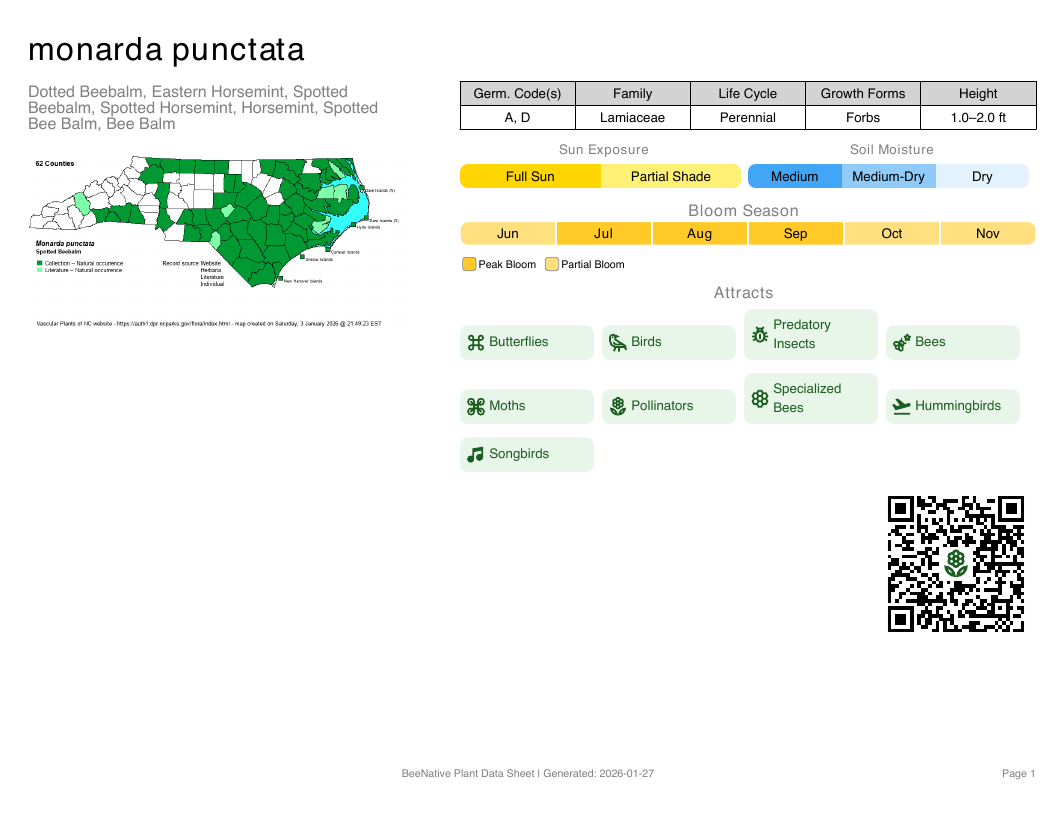

In [468]:
import pdf2image

images = pdf2image.convert_from_path(pdf_filename, dpi=96)

display(images[0])

# Testing better parsing for NCSU

In [510]:
from bs4 import BeautifulSoup
from urllib.parse import urljoin


def process_ncsu_data(sci_name: str, content: str):
    """
    Parses plant information from the content already present in the row.
    """

    if not content:
        return None

    soup = BeautifulSoup(content, "html.parser")
    formatted_name = sci_name.lower().replace(" ", "-")
    data = {"scientific_name": sci_name}

    # 2. Parse "Other Common Name(s)"
    common_names_div = soup.find("div", class_="common_name_space")
    if common_names_div:
        names_list = common_names_div.find("ul", id="common_names")
        if names_list:
            data["other_common_names"] = [li.get_text(strip=True) for li in names_list.find_all("li")]

    # 3. Parse Phonetic Spelling
    phonetic_dt = soup.find("dt", string="Phonetic Spelling")
    if phonetic_dt:
        data["phonetic_spelling"] = phonetic_dt.find_next_sibling("dd").get_text(strip=True)

    # 4. Parse Description
    description_dt = soup.find("dt", string="Description")
    if description_dt:
        dd_content = description_dt.find_next_sibling("dd")

        # 1. Configuration
        base_url = "https://plants.ces.ncsu.edu"  # Change this to your target site
        block_tags = {"p", "div", "dd", "section", "article"}
        break_tags = {"br", "li"}
        output = []
        processed_ids = set()

        # 2. Iterate through elements
        for element in dd_content.descendants:
            if id(element) in processed_ids:
                continue

            # Handle Link Tags
            if element.name == "a":
                link_text = element.get_text(strip=True)
                href = element.get("href", "")
                # Convert relative (/path) to absolute (https://site.com/path)
                full_url = urljoin(base_url, href) if href else ""

                # Mark children as processed so we don't grab the text again
                for child in element.descendants:
                    processed_ids.add(id(child))

                if link_text and full_url:
                    output.append(f"{link_text} ({full_url})")
                elif link_text:
                    output.append(link_text)

            # Handle Block/Break Tags
            elif element.name in block_tags:
                output.append("\n\n")
            elif element.name in break_tags:
                output.append("\n")

            # Handle Plain Text
            elif isinstance(element, str):
                text = " ".join(element.split())
                if text:
                    output.append(text)

        # 3. The "Clean Join"
        # This prevents "onMonarda" by forcing a space between every chunk
        raw_text = " ".join(output)

        # 4. Final Polish
        final_text = re.sub(r" +", " ", raw_text)  # Collapse multi-spaces
        final_text = re.sub(r"\s+([,.!?;:])", r"\1", final_text)  # Fix "word ." -> "word."
        final_text = re.sub(r"\s*\n\s*", "\n", final_text)  # Trim space around newlines
        final_text = re.sub(r"\n{1,}", "\n\n", final_text).strip()

        print(final_text)

        # data['description'] = description_dt.find_next_sibling('dd').get_text(strip=True)

        # Replace <br> tags with actual newlines before extracting text
        # for paragraph in dd_content.find_all("p"):
        #     # print(paragraph)
        #     paragraph += "\n"

        # print(dd_content)
        # Extract text using a newline separator for block elements
        # strip=True cleans individual chunks but keeps our new separators
        # raw_desc = dd_content.get_text(separator="\n", strip=True)
        # print(raw_desc)
        # data['description'] = raw_desc

        # Clean up double/triple newlines caused by nested tags
        # data['description'] = "\n".join([line.strip() for line in raw_desc.splitlines() if line.strip()])
    print(data["description"])

In [478]:
input_ncsu_file = Path("ncsu_plant_data.parquet")
ncsu_input_df = pl.read_parquet(input_ncsu_file)

In [511]:
sci_name = "Monarda punctata"
row_dict = ncsu_input_df.row(by_predicate=(pl.col("scientific_name") == sci_name), named=True)
process_ncsu_data(sci_name, row_dict["content"])

Spotted beebalm is an herbaceous perennial in the mint family (Lamiaceae). It is native to the eastern United 
States, from New Jersey to southern Florida and west to Texas. Several varieties are recognized, but only var. 
punctata occurs in NC. Generally found in prairies, sandy areas, rocky woodlands and coastal plains. The specific 
epithet is Latin for “spotted” and references the violet speckles that dot the corolla.

Spotted beebalm typically occurs in full sun to part shade areas. It prefers moist soil but will tolerate 
occasionally dry sites. It is a drought-tolerant but short-lived plant.

Spotted beebalm is a clump-forming plant that typically grows 1.5 to 2 feet tall. It spreads by rhizomes to form 
large clumps, but is not considered to be too aggressive. Spotted beebalm is in bloom from summer to fall and makes
excellent cut flowers. Remove spent flowers to improve plant appearance and possibly to prolong bloom. This species
is very attractive to butterflies, wasps, hummingbirds and bees. It is the host plant for the larvae of both the 
gray marvel (Anterastria teratophora) 
(https://bugguide.net/index.php?q=search&keys=Anterastria+teratophora&search=Search) and the snout (Pyrausta 
generosa) (https://bugguide.net/index.php?q=search&keys=Pyrausta+generosa) moths.

Use spotted beebalm in borders and mass plantings in pollinator, butterfly, rain, cottage or night gardens.

Fire Risk: This plant has a medium flammability rating.

Insects, Diseases, and Other Plant Problems: Plants are susceptible to powdery mildew and rust, especially in 
crowded gardens, but it is usually in the late season after flowering. Prune stems to increase airflow. In 
addition, drought-stressed plants are more susceptible to disease than plants growing with ample water.

More information onMonarda (https://plants.ces.ncsu.edu/plants/monarda/).

KeyError: 'description'

# NCBG

In [512]:
def process_ncbg_data(scientific_name: str, content: str):
    """
    Parses plant information from the content already present in the row.
    """
    if not content:
        return None

    soup = BeautifulSoup(content, "html.parser")
    data = {"scientific_name": scientific_name}

    # 1. Extract Permalink
    permalink_div = soup.find("div", id="permalink")
    data["permalink"] = permalink_div.get_text(strip=True) if permalink_div else None

    # 2. Extract Image Information
    image_list = []
    # Each image and its metadata is wrapped in an 'img-container' div
    containers = soup.find_all("div", class_="img-container")

    for container in containers:
        # Skip the distribution map (it uses an <object> tag rather than <img>)
        img_tag = container.find("img")
        if not img_tag:
            continue

        img_metadata = {
            "thumbnail_url": img_tag.get("src"),
            # The high-res link is usually the last <a> tag in the container
            "original_url": None,
            "copyright": None,
            "source_url": None,
            "license": None,
        }

        # Extract high-res link
        orig_link = container.find("a", title=lambda x: x and "original" in x.lower())
        if orig_link:
            img_metadata["original_url"] = orig_link.get("href")

        # Extract copyright/attribution from the span with 'auditlog' in the ID
        caption_span = container.find("span", id=lambda x: x and "auditlog" in x)
        if caption_span:
            img_metadata["copyright"] = caption_span.get_text(strip=True)

        # Extract External Source (e.g., iNaturalist)
        source_link = container.find("a", string=lambda x: x and "source" in x.lower())
        if source_link:
            img_metadata["source_url"] = source_link.get("href")

        # Extract License (e.g., CC-BY)
        license_link = container.find("a", href=lambda x: x and "creativecommons" in x)
        if license_link:
            img_metadata["license"] = license_link.get_text(strip=True)

        image_list.append(img_metadata)

    # Store images as a list of dicts (Polars can handle this as a List/Struct column)
    data["images"] = image_list

    return data

In [513]:
file_path = "crawls/Sabatia calycina_ncbg.html"

try:
    with open(file_path, "r", encoding="utf-8") as f:
        html_content = f.read()

    # Run the processor
    result = process_ncbg_data("Zizaniopsis miliacea", html_content)

    # Print formatted JSON for easy inspection
    print(json.dumps(result, indent=4))

except FileNotFoundError:
    print(f"File {file_path} not found. Please ensure it is in the same directory.")

{
    "scientific_name": "Zizaniopsis miliacea",
    "permalink": 
"https://fsus.ncbg.unc.edu/main.php?pg=show-taxon-detail.php&lsid=urn:lsid:ncbg.unc.edu:taxon:{578B7B0D-361A-43E8-A
86C-1F574A0FF3AB}",
    "images": [
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/kb/kb_03449.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/kb/kb_03449.jpg",
            "copyright": "\u00a9 Keith Bradley",
            "source_url": null,
            "license": null
        },
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/userimg/userimg_314870.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/userimg/userimg_314870.jpg",
            "copyright": "\u00a9 Mary Keim, some rights reserved (CC BY-NC-SA)",
            "source_url": "https://www.inaturalist.org/observations/118866022",
            "license": "CC-BY-NC-SA, permission granted to NCBG"
        },
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/userimg/userimg_314873.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/userimg/userimg_314873.jpg",
            "copyright": "\u00a9 Lauren McLaurin, some rights reserved (CC BY), uploaded by Lauren McLaurin",
            "source_url": "https://www.inaturalist.org/observations/46869297",
            "license": "CC-BY"
        },
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/userimg/userimg_314871.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/userimg/userimg_314871.jpg",
            "copyright": "\u00a9 Eric M Powell, some rights reserved (CC BY-NC), uploaded by Eric M Powell",
            "source_url": "https://www.inaturalist.org/observations/28081225",
            "license": "CC-BY-NC, permission granted to NCBG"
        },
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/userimg/userimg_314869.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/userimg/userimg_314869.jpg",
            "copyright": "\u00a9 Mary Keim, some rights reserved (CC BY-NC-SA)",
            "source_url": "https://www.inaturalist.org/observations/202666088",
            "license": "CC-BY-NC-SA, permission granted to NCBG"
        },
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/gpf/gpf_07092.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/gpf/gpf_07092.jpg",
            "copyright": "\u00a9 Gary P. Fleming",
            "source_url": null,
            "license": null
        },
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/fg/fg_00452.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/fg/fg_00452.jpg",
            "copyright": "\u00a9 Floyd A. Griffith",
            "source_url": null,
            "license": null
        },
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/userimg/userimg_314867.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/userimg/userimg_314867.jpg",
            "copyright": "\u00a9 Shaun Pogacnik, some rights reserved (CC BY-NC), uploaded by Shaun Pogacnik",
            "source_url": "https://www.inaturalist.org/observations/310755757",
            "license": "CC-BY-NC, permission granted to NCBG"
        },
        {
            "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/userimg/userimg_314865.jpg",
            "alt_text": "image of plant",
            "original_url": "https://fsus.ncbg.unc.edu/img/orig/userimg/userimg_314865.jpg",
            "copyright": "\u00a9 Shaun Pogacnik, some rights reserved (CC BY-NC), uploaded by Shaun Pogac

In [ ]:
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/bas/bas_03344.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/bas/bas_03344.jpg",
    "copyright": "© Bruce A. Sorrie",
    "source_url": None,
    "license": None,
}
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/rtw/rtw_00621.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/rtw/rtw_00621.jpg",
    "copyright": "© Richard & Teresa Ware",
    "source_url": None,
    "license": "CC-BY-NC, permission granted to NCBG",
}
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/rtw/rtw_00618.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/rtw/rtw_00618.jpg",
    "copyright": "© Richard & Teresa Ware",
    "source_url": None,
    "license": "CC-BY-NC, permission granted to NCBG",
}
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/gpf/gpf_05251.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/gpf/gpf_05251.jpg",
    "copyright": "© Gary P. Fleming",
    "source_url": None,
    "license": None,
}
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/bas/bas_03345.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/bas/bas_03345.jpg",
    "copyright": "© Bruce A. Sorrie",
    "source_url": None,
    "license": None,
}
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/eb/eb_01186.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/eb/eb_01186.jpg",
    "copyright": "© Edwin Bridges",
    "source_url": None,
    "license": None,
}
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/amc/amc_06095.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/amc/amc_06095.jpg",
    "copyright": "© Alan Cressler: Monarda didyma, Cohutta Wilderness, Chattahoochee National Forest, Murray County, Georgia 1 by Alan Cressler",
    "source_url": "https://www.flickr.com/photos/alan_cressler/48451044692/",
    "license": None,
}
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/gpf/gpf_05250.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/gpf/gpf_05250.jpg",
    "copyright": "© Gary P. Fleming",
    "source_url": None,
    "license": None,
}
{
    "thumbnail_url": "https://fsus.ncbg.unc.edu/img/600/jsh/jsh_03774.jpg",
    "original_url": "https://fsus.ncbg.unc.edu/img/orig/jsh/jsh_03774.jpg",
    "copyright": "© Joey Shaw",
    "source_url": "https://inaturalist.org/observations/51458062",
    "license": None,
}

In [522]:
import polars as pl

# Load just the schema
df = pl.read_parquet("merged.parquet")
print("SCHEMA_START")
for col, dtype in df.schema.items():
    print(f"{col}: {dtype}")
print("SCHEMA_END")

# Also, show a sample of one row to see the data format
print("\nSAMPLE_ROW:")
print(df.head(1).to_dicts()[0])

SCHEMA_START

scientific_name: String

pm_Common Name: String

pm_Catalog Code: String

pm_About: String

...

ncbg_permalink: String

ncbg_images: List(Struct({'thumbnail_url': String, 'original_url': String, 'copyright': String, 'source_url': 
String, 'license': String, 'title': String, 'author': String, 'license_text': String, 'license_url': String, 
'is_standard': Boolean}))

SCHEMA_END

SAMPLE_ROW:

{
    'scientific_name': 'huperzia appressa',
    'pm_Common Name': None,
    'pm_Catalog Code': None,
    'pm_About': None,
    'pm_Bloom Color': None,
    'pm_Bloom Time': None,
    'pm_Life Cycle': None,
    'pm_Native States': None,
    'pm_Height': None,
    'pm_Sun Exposure': None,
    'pm_Soil Moisture': None,
    'pm_Germination Code': None,
    'pm_adv_bee': None,
    'pm_adv_bird': None,
    'pm_adv_deer': None,
    'pm_adv_stars': None,
    'pm_imageUrl': None,
    'pm_URL': None,
    'ncsu_url': None,
    'ncsu_other_common_names': None,
    'ncsu_phonetic_spelling': None,
    'ncsu_html_description': None,
    'ncsu_description': None,
    'ncsu_cultivars': None,
    'ncsu_Genus': None,
    'ncsu_Species': None,
    'ncsu_Family': None,
    'ncsu_Uses (Ethnobotany)': None,
    'ncsu_Life Cycle': None,
    'ncsu_Recommended Propagation Strategy': None,
    'ncsu_Country Or Region Of Origin': None,
    'ncsu_Distribution': None,
    'ncsu_Wildlife Value': None,
    'ncsu_Edibility': None,
    'ncsu_Dimensions': None,
    'ncsu_Plant Type': None,
    'ncsu_Habit/Form': None,
    'ncsu_Growth Rate': None,
    'ncsu_Maintenance': None,
    'ncsu_Texture': None,
    'ncsu_Light': None,
    'ncsu_Soil Texture': None,
    'ncsu_Soil Drainage': None,
    'ncsu_Available Space To Plant': None,
    'ncsu_NC Region': None,
    'ncsu_USDA Plant Hardiness Zone': None,
    'ncsu_Fruit Color': None,
    'ncsu_Display/Harvest Time': None,
    'ncsu_Fruit Type': None,
    'ncsu_Fruit Length': None,
    'ncsu_Fruit Description': None,
    'ncsu_Flower Color': None,
    'ncsu_Flower Inflorescence': None,
    'ncsu_Flower Value To Gardener': None,
    'ncsu_Flower Bloom Time': None,
    'ncsu_Flower Shape': None,
    'ncsu_Flower Petals': None,
    'ncsu_Flower Size': None,
    'ncsu_Flower Description': None,
    'ncsu_Leaf Color': None,
    'ncsu_Leaf Value To Gardener': None,
    'ncsu_Leaf Type': None,
    'ncsu_Leaf Arrangement': None,
    'ncsu_Leaf Shape': None,
    'ncsu_Leaf Margin': None,
    'ncsu_Hairs Present': None,
    'ncsu_Leaf Length': None,
    'ncsu_Leaf Width': None,
    'ncsu_Leaf Description': None,
    'ncsu_Stem Color': None,
    'ncsu_Stem Is Aromatic': None,
    'ncsu_Stem Cross Section': None,
    'ncsu_Stem Form': None,
    'ncsu_Stem Description': None,
    'ncsu_Landscape Location': None,
    'ncsu_Landscape Theme': None,
    'ncsu_Design Feature': None,
    'ncsu_Attracts': None,
    'ncsu_Poison Severity': None,
    'ncsu_Poison Symptoms': None,
    'ncsu_Poison Toxic Principle': None,
    'ncsu_Causes Contact Dermatitis': None,
    'ncsu_Poison Part': None,
    'ncsu_Soil pH': None,
    'ncsu_Fruit Width': None,
    'ncsu_Leaf Feel': None,
    'ncsu_Resistance To Challenges': None,
    'ncsu_Fire Risk Rating': None,
    'ncsu_Woody Plant Leaf Characteristics': None,
    'ncsu_Deciduous Leaf Fall Color': None,
    'ncsu_Bark Color': None,
    'ncsu_Surface/Attachment': None,
    'ncsu_Bark Description': None,
    'ncsu_Stem Surface': None,
    'ncsu_Problems': None,
    'ncsu_Particularly Resistant To (Insects/Diseases/Other Problems)': None,
    'ncsu_Play Value': None,
    'ncsu_Fruit Value To Gardener': None,
    'ncsu_Stem Bud Scales': None,
    'ncsu_Climbing Method': None,
    'ncsu_Appendage': None,
    'ncsu_Stem Buds': None,
    'ncsu_Bark Plate Shape': None,
    'ncsu_Stem Bud Terminal': None,
    'ncsu_Stem Lenticels': None,
    'ncsu_images': None,
    'vasc_id': '4201',
    'vasc_common_name_primary': 'Appalachian Firmoss',
    'vasc_author': '(Desvaux) A. Love & D. Love',
    'vasc_distribution': 'Essentially throughout the Mountains, and possibly into the adjacent Piedmont. This is a 
Northern species, ranging from eastern Canada south only to NY and MN, but disjunct to the mountains of VA, NC, TN,
and northeastern GA.',
    'vasc_abundance': 'Infrequent to locally fairly common, though with somewhat restricted habitats.  This is a 
Watch List species.',
    'vasc_habitat': 'This species